<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">Analysez les ventes d'une librairie avec Python</h1>
</div>

# BRIEF ANABELLE

Nous souhaitons élaborer différents graphiques autour du chiffre d'affaires comme par exemples l’évolution dans le temps du :<BR>
● chiffre d’affaires avec la moyenne mobile (tu pourras choisir la période : jour, semaine, mois, etc.),<BR>
● chiffre d’affaires par catégorie,<BR>
● nombre de clients par mois,<BR>
● nombre de transactions,<BR>
● nombre de produits vendus,<BR>
● etc.<BR><BR>
Il serait également intéressant de faire un zoom sur les références :<BR>
● les tops,<BR>
● les flops,<BR>
● la répartition par catégorie,<BR>
● etc.<BR><BR>
Enfin, j’aimerais avoir quelques informations sur les profils de nos clients :<BR>
● répartition du chiffre d'affaires pour les clients BtoB,<BR>
● courbe de Lorenz,<BR>
● etc.<BR>
Après, toutes les informations et tous graphiques qui apporteraient de l’information pertinente sont les bienvenus !

# COMPLEMENT JULIE

5 corrélations :<BR>
● le lien entre le genre d’un client et les catégories des livres achetés,<BR>
● le lien entre l'âge des clients et le montant total des achats,<BR>
● le lien entre l'âge des clients et la fréquence d’achat,<BR>
● le lien entre l'âge des clients et la taille du panier moyen,<BR>
● et pour finir le lien entre l'âge des clients et la catégorie des livres achetés.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.colors as mcolors
from scipy.stats import pearsonr

In [9]:
!pip install scikit-posthocs

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [11]:
import os
print(os.getcwd())

C:\Users\t_rak\Documents


In [12]:
#Importation datasets
df_products = pd.read_csv("p9_products.csv", sep=";")
df_customers = pd.read_csv("p9_customers.csv", sep=";")
df_transactions = pd.read_csv("p9_Transactions.csv", sep=";")

C:\Users\t_rak\AppData\Local\Temp\ipykernel_28132\1415768471.py:4: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_transactions = pd.read_csv("p9_Transactions.csv", sep=";")


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire et pré-traitement des datasets</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Dataset products</h3>
</div>

In [15]:
#Dimensions
print("Le tableau comporte {} observation(s) ou article(s)".format(df_products.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_products.shape[1]))

Le tableau comporte 3286 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [16]:
#aperçu df
df_products.head(5)

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [17]:
#résumé global
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [18]:
#COLONNE PRICE résumé stats
df_products['price'].describe()

count    3286.000000
mean       21.863597
std        29.849786
min         0.620000
25%         6.990000
50%        13.075000
75%        22.990000
max       300.000000
Name: price, dtype: float64

In [19]:
#COLONNE PRICE prix min vs prix max
print("Le prix minimum est : {} euros".format(df_products['price'].min()))
print("Le prix minimum est : {} euros".format(df_products['price'].max()))

Le prix minimum est : 0.62 euros
Le prix minimum est : 300.0 euros


In [20]:
#COLONNE CATEG valeurs uniques
df_products['categ'].unique()

array([0, 1, 2], dtype=int64)

In [21]:
#COLONNE CATEG à quoi correspondent ces catégories ? Pas à des segments de prix. Creuser sur le df final
df_products.groupby("categ")["price"].agg(min_price=("min"), max_price=("max"), mean_price=("mean")).reset_index()

,categ,min_price,max_price,mean_price
0,0,0.62,40.99,11.732795
1,1,2.00,80.99,25.531421
2,2,30.99,300.00,108.354686


In [22]:
#COLONNE ID verif doublons
doublons_products = df_products[df_products.duplicated(subset='id_prod', keep=False)]
doublons_products

,id_prod,price,categ


In [23]:
#COLONNE ID double verif doublons
print(f"Nb de valeurs uniques dans 'id_prod' : {df_products['id_prod'].nunique()} vs Nb de lignes dans le dataset : {len(df_products)}")

Nb de valeurs uniques dans 'id_prod' : 3286 vs Nb de lignes dans le dataset : 3286


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Dataset customers</h3>
</div>

In [25]:
#Dimensions
print("Le tableau comporte {} observation(s) ou article(s)".format(df_customers.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_customers.shape[1]))

Le tableau comporte 8621 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [26]:
#Aperçu
df_customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [27]:
#résumé global
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [28]:
#COLONNE BIRTH verif année min et max
print("ADN min : {}".format(df_customers['birth'].min()))
print("ADN max : {}".format(df_customers['birth'].max()))

ADN min : 1929
ADN max : 2004


In [29]:
#COLONNE BIRTH calcul colonne Age pour visualisation segmentation age
from datetime import datetime

# Récupérer l'année actuelle
annee_actuelle = datetime.now().year

# Calculer l'âge
df_customers['Age'] = annee_actuelle - df_customers['birth']
df_customers

,client_id,sex,birth,Age
0,c_4410,f,1967,58
1,c_7839,f,1975,50
2,c_1699,f,1984,41
3,c_5961,f,1962,63
4,c_5320,m,1943,82
...,...,...,...,...
8616,c_7920,m,1956,69
8617,c_7403,f,1970,55
8618,c_5119,m,1974,51
8619,c_5643,f,1968,57


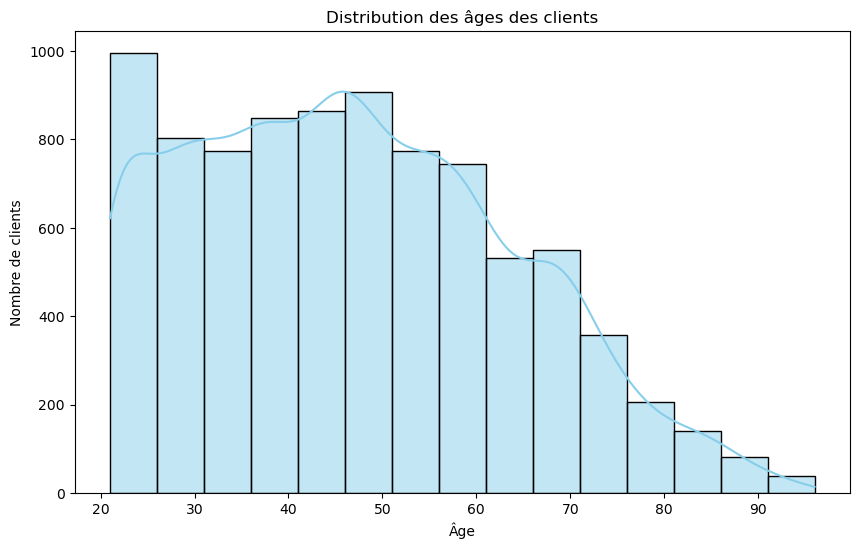

In [30]:
#COLONNE AGE dataviz repartition
plt.figure(figsize=(10, 6))
sns.histplot(df_customers['Age'], bins=15, kde=True, color='skyblue')
plt.title("Distribution des âges des clients")
plt.xlabel("Âge")
plt.ylabel("Nombre de clients")
plt.show()

In [31]:
#COLONNE SEX verif valeurs uniques
df_customers['sex'].unique()

array(['f', 'm'], dtype=object)

In [32]:
#COLONNE SEX répartition hommes femmes
# Comptage des occurrences
counts = df_customers['sex'].value_counts()
total = len(df_customers)

# Calcul des pourcentages
pourcentage_femmes = (counts.get('f', 0) / total) * 100
pourcentage_hommes = (counts.get('m', 0) / total) * 100

# Affichage
print(f"Pourcentage de femmes : {pourcentage_femmes:.2f}%")
print(f"Pourcentage d'hommes : {pourcentage_hommes:.2f}%")

Pourcentage de femmes : 52.08%
Pourcentage d'hommes : 47.92%


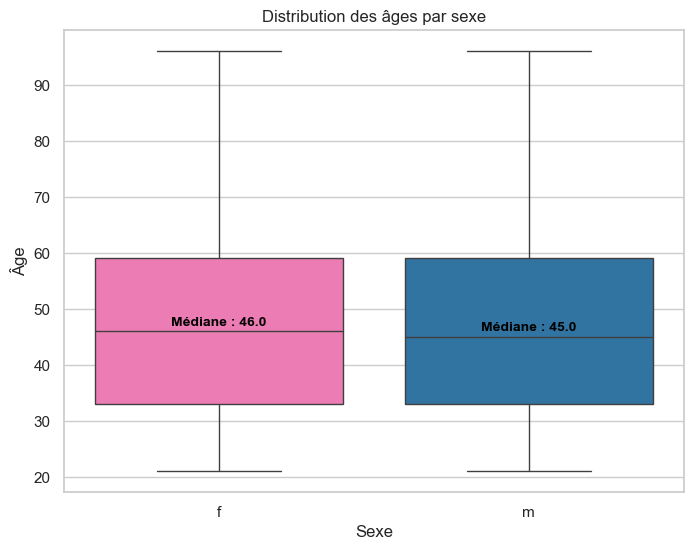

In [33]:
# SEX AGE dataviz distribution
# Style
sns.set(style="whitegrid")

# Création du boxplot avec hue et palette personnalisée
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='sex', y='Age', hue='sex', data=df_customers,
                 palette={'f': '#ff69b4', 'm': '#1f77b4'}, legend=False)

# Calcul et annotation des âges médians
medians = df_customers.groupby('sex')['Age'].median()
for i, sex in enumerate(medians.index):
    median_val = medians[sex]
    ax.text(i, median_val + 1, f'Médiane : {median_val}', ha='center',
            fontsize=10, color='black', weight='semibold')

# Titres et axes
plt.title('Distribution des âges par sexe')
plt.xlabel('Sexe')
plt.ylabel('Âge')
plt.show()

In [34]:
#COLONNE ID CLIENTS verif doublons
doublons_customers = df_customers[df_customers.duplicated(subset='client_id', keep=False)]
doublons_customers

,client_id,sex,birth,Age


In [35]:
#COLONNE ID CLIENTS double verif doublons
print(f"Nb de valeurs uniques dans 'client_id' : {df_customers['client_id'].nunique()} vs Nb de lignes dans le dataset : {len(df_customers)}")

Nb de valeurs uniques dans 'client_id' : 8621 vs Nb de lignes dans le dataset : 8621


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Dataset transactions</h3>
</div>

In [37]:
#Dimensions
print("Le tableau comporte {} observation(s) ou article(s)".format(df_transactions.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_transactions.shape[1]))

Le tableau comporte 1048575 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [38]:
#Aperçu
df_transactions.head()

,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


In [39]:
#résumé global
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     687534 non-null  object
 1   date        687534 non-null  object
 2   session_id  687534 non-null  object
 3   client_id   687534 non-null  object
dtypes: object(4)
memory usage: 32.0+ MB


In [40]:
#Controles des cellules vides par colonne
colonnes = ['id_prod', 'date', 'session_id', 'client_id']

# Comptage des NaN
nan_counts = df_transactions[colonnes].isna().sum()

# Affichage
for col in colonnes:
    print(f"Nombre de valeurs manquantes dans '{col}' : {nan_counts[col]}")

Nombre de valeurs manquantes dans 'id_prod' : 361041
Nombre de valeurs manquantes dans 'date' : 361041
Nombre de valeurs manquantes dans 'session_id' : 361041
Nombre de valeurs manquantes dans 'client_id' : 361041


In [41]:
#Controle des lignes entièrement vides
colonnes = ['id_prod', 'date', 'session_id', 'client_id']

# Filtrer les lignes où toutes les colonnes sont NaN
nb_lignes_nan_total = df_transactions[colonnes].isna().all(axis=1).sum()

print(f"Nombre de lignes où les 4 colonnes sont NaN : {nb_lignes_nan_total}")

Nombre de lignes où les 4 colonnes sont NaN : 361041


In [42]:
# Supprimer les lignes où les 4 colonnes sont toutes NaN
df_transactions = df_transactions[~df_transactions[colonnes].isna().all(axis=1)]

In [43]:
#Controles des cellules vides par colonne APRES SUPPRESSION LIGNES NAN
colonnes = ['id_prod', 'date', 'session_id', 'client_id']

# Comptage des NaN
nan_counts = df_transactions[colonnes].isna().sum()

# Affichage
for col in colonnes:
    print(f"Nombre de valeurs manquantes dans '{col}' : {nan_counts[col]}")

Nombre de valeurs manquantes dans 'id_prod' : 0
Nombre de valeurs manquantes dans 'date' : 0
Nombre de valeurs manquantes dans 'session_id' : 0
Nombre de valeurs manquantes dans 'client_id' : 0


In [44]:
#COLONNE DATE verif du format des valeurs date
import re

# Définir le motif attendu
pattern = r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{6}$"

# Vérifier chaque valeur
invalid_dates = df_transactions['date'].dropna().apply(lambda x: not bool(re.match(pattern, str(x))))

# Compter les valeurs non conformes
nb_invalid = invalid_dates.sum()
print(f"Nombre de dates non conformes : {nb_invalid}")

Nombre de dates non conformes : 87


In [45]:
#COLONNE DATE affichage des dates non conformes pour trouver le problème
# Motif attendu
pattern = r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{6}$"

# Filtrer les lignes non conformes
invalid_date_rows = df_transactions[df_transactions['date'].dropna().apply(lambda x: not bool(re.match(pattern, str(x))))]

# Afficher les lignes concernées
invalid_date_rows

,id_prod,date,session_id,client_id
196092,1_111,2021-10-01 05:13:9.438723,s_98272,c_6695
196335,1_612,2021-10-01 09:53:6.991197,s_98355,c_4554
196355,1_225,2021-10-01 10:22:3.713025,s_98364,c_4958
196575,1_426,2021-10-01 14:38:1.424583,s_98464,c_1326
196577,1_445,2021-10-01 14:38:7.604429,s_98464,c_1326
...,...,...,...,...
222494,1_661,2021-10-28 17:04:9.314938,s_111409,c_4343
222974,1_413,2021-10-29 03:57:6.330350,s_111626,c_7757
223244,1_553,2021-10-29 10:36:8.146248,s_111761,c_3347
223867,1_267,2021-10-30 00:14:9.552439,s_112042,c_1063


<span style="color:red"><strong>Non conforme car il manque un 0 dans l'unité des secondes.<br>
Extraire les années mois jour malgré cela et faire un check a posteriori</strong></span>

In [47]:
#COLONNE DATE extraction année/mois/jour et conversion jour_lettre
# Conversion en datetime
df_transactions['date'] = pd.to_datetime(df_transactions['date'], errors='coerce')

# Extraction
df_transactions['annee'] = df_transactions['date'].dt.year
df_transactions['mois'] = df_transactions['date'].dt.month
df_transactions['jour'] = df_transactions['date'].dt.day
df_transactions['jour_lettre'] = df_transactions['date'].dt.day_name()
df_transactions['mois_lettre'] = df_transactions['date'].dt.month_name()
df_transactions

,id_prod,date,session_id,client_id,annee,mois,jour,jour_lettre,mois_lettre
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021,3,1,Monday,March
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021,3,1,Monday,March
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021,3,1,Monday,March
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021,3,1,Monday,March
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021,3,1,Monday,March
...,...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,2023,2,28,Tuesday,February
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,2023,2,28,Tuesday,February
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,2023,2,28,Tuesday,February
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,2023,2,28,Tuesday,February


In [48]:
#COLONNE JOUR LETTRE Traduction manuelle des jours en français
jours_fr = {
    'Monday': 'Lundi',
    'Tuesday': 'Mardi',
    'Wednesday': 'Mercredi',
    'Thursday': 'Jeudi',
    'Friday': 'Vendredi',
    'Saturday': 'Samedi',
    'Sunday': 'Dimanche'
}

# Extraire les jours en anglais puis traduire
df_transactions['jour_lettre'] = df_transactions['date'].dt.day_name().map(jours_fr)

In [49]:
#COLONNE MOIS LETTRE Traduction manuelle des mois en français
mois_fr = {
    'January': 'Janvier', 
    'February': 'Février', 
    'March': 'Mars', 
    'April': 'Avril',
    'May': 'Mai', 
    'June': 'Juin', 
    'July': 'Juillet', 
    'August': 'Août',
    'September': 'Septembre', 
    'October': 'Octobre', 
    'November': 'Novembre', 
    'December': 'Décembre'
}

# Extraire les mois en anglais puis traduire
df_transactions['mois_lettre'] = df_transactions['date'].dt.month_name().map(mois_fr)

In [50]:
#Aperçu
df_transactions

,id_prod,date,session_id,client_id,annee,mois,jour,jour_lettre,mois_lettre
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,2021,3,1,Lundi,Mars
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,2021,3,1,Lundi,Mars
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,2021,3,1,Lundi,Mars
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,2021,3,1,Lundi,Mars
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,2021,3,1,Lundi,Mars
...,...,...,...,...,...,...,...,...,...
687529,1_508,2023-02-28 23:49:03.148402,s_348444,c_3573,2023,2,28,Mardi,Février
687530,2_37,2023-02-28 23:51:29.318531,s_348445,c_50,2023,2,28,Mardi,Février
687531,1_695,2023-02-28 23:53:18.929676,s_348446,c_488,2023,2,28,Mardi,Février
687532,0_1547,2023-02-28 23:58:00.107815,s_348447,c_4848,2023,2,28,Mardi,Février


In [51]:
#Aperçu
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 687534 entries, 0 to 687533
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id_prod      687534 non-null  object        
 1   date         687534 non-null  datetime64[ns]
 2   session_id   687534 non-null  object        
 3   client_id    687534 non-null  object        
 4   annee        687534 non-null  int32         
 5   mois         687534 non-null  int32         
 6   jour         687534 non-null  int32         
 7   jour_lettre  687534 non-null  object        
 8   mois_lettre  687534 non-null  object        
dtypes: datetime64[ns](1), int32(3), object(5)
memory usage: 44.6+ MB


In [52]:
#Verif année première transaction et la plus récente
print("Année début transaction : {}".format(df_transactions['annee'].min()))
print("Année dernière transaction : {}".format(df_transactions['annee'].max()))

Année début transaction : 2021
Année dernière transaction : 2023


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction products -> transactions</h3>
</div>

In [55]:
#Rappel dimensions
print("Le tableau comporte {} observation(s) ou article(s)".format(df_products.shape[0]))
print("Le tableau comporte {} observation(s) ou article(s)".format(df_transactions.shape[0]))

Le tableau comporte 3286 observation(s) ou article(s)
Le tableau comporte 687534 observation(s) ou article(s)


In [56]:
#jointure EXTERNE COMPLETE AVEC INDICATEURS
df_prod_trans = df_transactions.merge(df_products, on='id_prod', how='outer', indicator=True)

In [57]:
#Vérification du nb de lignes ayant été appairées
df_prod_trans['_merge'].value_counts()

_merge
both          687534
right_only        21
left_only          0
Name: count, dtype: int64

In [58]:
#Verif des produits non vendus en 3 ans pour conseil gestion de stock
df_prod_trans_right_only = df_prod_trans[df_prod_trans['_merge'] == 'right_only']
df_prod_trans_right_only

,id_prod,date,session_id,client_id,annee,mois,jour,jour_lettre,mois_lettre,price,categ,_merge
6073,0_1014,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.15,0,right_only
6511,0_1016,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.06,0,right_only
8723,0_1025,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.99,0,right_only
21687,0_1062,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.08,0,right_only
40971,0_1119,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.99,0,right_only
94245,0_1318,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.92,0,right_only
297077,0_1620,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.80,0,right_only
299185,0_1624,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.50,0,right_only
311123,0_1645,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.99,0,right_only
323013,0_1780,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.67,0,right_only


In [59]:
#Filtre du df sur la valeur "both" (correspondance parfaite entre les id_prod)
df_prod_trans_vf = df_prod_trans[df_prod_trans['_merge'] == 'both']

<span style="color:green"><strong>OK. Nous retrouvons le même nb de lignes dans le df transactions initial et le df fusionné : aucune perte des transactions</strong></span>

In [61]:
#Suppression colonne _merge car conflit pour prochaine fusion
df_prod_trans_vf = df_prod_trans_vf.drop(columns=['_merge'])
df_prod_trans_vf

,id_prod,date,session_id,client_id,annee,mois,jour,jour_lettre,mois_lettre,price,categ
0,0_0,2021-03-01 13:45:51.575117,s_282,c_5152,2021.0,3.0,1.0,Lundi,Mars,3.75,0
1,0_0,2021-03-02 06:42:55.351333,s_621,c_2917,2021.0,3.0,2.0,Mardi,Mars,3.75,0
2,0_0,2021-03-02 18:49:49.651862,s_852,c_3988,2021.0,3.0,2.0,Mardi,Mars,3.75,0
3,0_0,2021-03-02 21:57:33.862118,s_908,c_1004,2021.0,3.0,2.0,Mardi,Mars,3.75,0
4,0_0,2021-03-03 23:59:48.997483,s_1379,c_278,2021.0,3.0,3.0,Mercredi,Mars,3.75,0
...,...,...,...,...,...,...,...,...,...,...,...
687550,2_99,2022-05-21 01:53:46.967570,s_211661,c_5828,2022.0,5.0,21.0,Samedi,Mai,84.99,2
687551,2_99,2022-07-21 01:53:46.967570,s_241374,c_5828,2022.0,7.0,21.0,Jeudi,Juillet,84.99,2
687552,2_99,2022-11-11 20:56:49.820935,s_296127,c_7135,2022.0,11.0,11.0,Vendredi,Novembre,84.99,2
687553,2_99,2022-12-11 20:56:49.820935,s_310606,c_7135,2022.0,12.0,11.0,Dimanche,Décembre,84.99,2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 bis - Jonction customers -> transactions pour vérification nb de lignes finales</h3>
</div>

In [63]:
#Rappel dimensions
print("Le tableau customers comporte {} observation(s) ou article(s)".format(df_customers.shape[0]))
print("Le tableau transactions comporte {} observation(s) ou article(s)".format(df_transactions.shape[0]))

Le tableau customers comporte 8621 observation(s) ou article(s)
Le tableau transactions comporte 687534 observation(s) ou article(s)


In [64]:
#jointure EXTERNE COMPLETE AVEC INDICATEURS
df_cust_trans = df_transactions.merge(df_customers, on='client_id', how='outer', indicator=True)

In [65]:
#Vérification du nb de lignes ayant été appairées
df_cust_trans['_merge'].value_counts()

_merge
both          687534
right_only        21
left_only          0
Name: count, dtype: int64

In [66]:
#Verif des clients n'ayant fait aucun achat de 2021 à 2023. Conseil pour suivi clientèle
df_cust_trans_right_only = df_cust_trans[df_cust_trans['_merge'] == 'right_only']
df_cust_trans_right_only

,id_prod,date,session_id,client_id,annee,mois,jour,jour_lettre,mois_lettre,sex,birth,Age,_merge
18399,NaN,NaT,NaN,c_1223,NaN,NaN,NaN,NaN,NaN,m,1963,62,right_only
167262,NaN,NaT,NaN,c_2706,NaN,NaN,NaN,NaN,NaN,f,1967,58,right_only
191551,NaN,NaT,NaN,c_3017,NaN,NaN,NaN,NaN,NaN,f,1992,33,right_only
225851,NaN,NaT,NaN,c_3443,NaN,NaN,NaN,NaN,NaN,m,1959,66,right_only
240172,NaN,NaT,NaN,c_3526,NaN,NaN,NaN,NaN,NaN,m,1956,69,right_only
261001,NaN,NaT,NaN,c_3789,NaN,NaN,NaN,NaN,NaN,f,1997,28,right_only
282271,NaN,NaT,NaN,c_4086,NaN,NaN,NaN,NaN,NaN,f,1992,33,right_only
305952,NaN,NaT,NaN,c_4358,NaN,NaN,NaN,NaN,NaN,m,1999,26,right_only
309172,NaN,NaT,NaN,c_4406,NaN,NaN,NaN,NaN,NaN,f,1998,27,right_only
312791,NaN,NaT,NaN,c_4447,NaN,NaN,NaN,NaN,NaN,m,1956,69,right_only


<span style="color:green"><strong>OK. Nous retrouvons le même nb de lignes dans le df transactions initial et le df fusionné : aucune perte des transactions</strong></span>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction finale df_prod_trans_vf -> customers</h3>
</div>

In [69]:
#Rappel dimensions
print("Le tableau customers comporte {} observation(s) ou article(s)".format(df_customers.shape[0]))
print("Le tableau initial transactions comporte {} observation(s) ou article(s)".format(df_transactions.shape[0]))
print("Le tableau fusionné produits/transactions comporte {} observation(s) ou article(s)".format(df_prod_trans_vf.shape[0]))

Le tableau customers comporte 8621 observation(s) ou article(s)
Le tableau initial transactions comporte 687534 observation(s) ou article(s)
Le tableau fusionné produits/transactions comporte 687534 observation(s) ou article(s)


In [70]:
#jointure LEFT pour garder tous les produits valides même s'il n'y a pas de correspondances clients
df_vf = df_prod_trans_vf.merge(df_customers, on='client_id', how='left', indicator=True)

In [71]:
#Verifi des lignes avec produits valides (id_prod) mais sans correspondance clients
df_vf['_merge'].value_counts()

_merge
both          687534
left_only          0
right_only         0
Name: count, dtype: int64

In [72]:
df_vf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id_prod      687534 non-null  object        
 1   date         687534 non-null  datetime64[ns]
 2   session_id   687534 non-null  object        
 3   client_id    687534 non-null  object        
 4   annee        687534 non-null  float64       
 5   mois         687534 non-null  float64       
 6   jour         687534 non-null  float64       
 7   jour_lettre  687534 non-null  object        
 8   mois_lettre  687534 non-null  object        
 9   price        687534 non-null  float64       
 10  categ        687534 non-null  int64         
 11  sex          687534 non-null  object        
 12  birth        687534 non-null  int64         
 13  Age          687534 non-null  int64         
 14  _merge       687534 non-null  category      
dtypes: category(1), datetime64[ns](1),

In [73]:
#Suppression colonne _merge
df_vf = df_vf.drop(columns=['_merge'])

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyses univariées</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.0 - Rappel structure df</h3>
</div>

In [76]:
#Rappel structure df final
df_vf.columns

Index(['id_prod', 'date', 'session_id', 'client_id', 'annee', 'mois', 'jour',
       'jour_lettre', 'mois_lettre', 'price', 'categ', 'sex', 'birth', 'Age'],
      dtype='object')

In [77]:
df_vf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id_prod      687534 non-null  object        
 1   date         687534 non-null  datetime64[ns]
 2   session_id   687534 non-null  object        
 3   client_id    687534 non-null  object        
 4   annee        687534 non-null  float64       
 5   mois         687534 non-null  float64       
 6   jour         687534 non-null  float64       
 7   jour_lettre  687534 non-null  object        
 8   mois_lettre  687534 non-null  object        
 9   price        687534 non-null  float64       
 10  categ        687534 non-null  int64         
 11  sex          687534 non-null  object        
 12  birth        687534 non-null  int64         
 13  Age          687534 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(6)
memory usage: 73.4+ MB


In [78]:
#Aperçu df final
df_vf.head()

,id_prod,date,session_id,client_id,annee,mois,jour,jour_lettre,mois_lettre,price,categ,sex,birth,Age
0,0_0,2021-03-01 13:45:51.575117,s_282,c_5152,2021.0,3.0,1.0,Lundi,Mars,3.75,0,f,1986,39
1,0_0,2021-03-02 06:42:55.351333,s_621,c_2917,2021.0,3.0,2.0,Mardi,Mars,3.75,0,m,1988,37
2,0_0,2021-03-02 18:49:49.651862,s_852,c_3988,2021.0,3.0,2.0,Mardi,Mars,3.75,0,f,1962,63
3,0_0,2021-03-02 21:57:33.862118,s_908,c_1004,2021.0,3.0,2.0,Mardi,Mars,3.75,0,m,1973,52
4,0_0,2021-03-03 23:59:48.997483,s_1379,c_278,2021.0,3.0,3.0,Mercredi,Mars,3.75,0,f,1987,38


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - CA avec moyenne mobile</h3>
</div>

<div style="border: 0px solid rgb(51,165,182);">
  <h4 style="margin: auto; padding: 10px; color: rgb(51,165,182);">🟦 CA Mensuel</h4>
</div>

In [81]:
# format datetime pour la colonne date (exploitable pour les data en date intelligence comme pbi)
df_vf['date'] = pd.to_datetime(df_vf['date'])

# Création d'une colonne 'year_month' pour l'agrégation mensuelle
df_vf['year_month'] = df_vf['date'].dt.to_period('M').astype(str)

# Agrégation du chiffre d'affaires mensuel
ca_mensuel = df_vf.groupby('year_month')['price'].sum().reset_index()
ca_mensuel['price'] = ca_mensuel['price'].round(2)

# Calcul de la moyenne mobile sur 3 mois
ca_mensuel['CA_moyenne_mobile'] = ca_mensuel['price'].rolling(window=3).mean()

ca_mensuel

,year_month,price,CA_moyenne_mobile
0,2021-03,482440.61,NaN
1,2021-04,476109.30,NaN
2,2021-05,492943.47,483831.126667
3,2021-06,484088.56,484380.443333
4,2021-07,482835.40,486622.476667
5,2021-08,482284.79,483069.583333
6,2021-09,507240.68,490786.956667
7,2021-10,494733.16,494752.876667
8,2021-11,516167.73,506047.190000
9,2021-12,525917.28,512272.723333


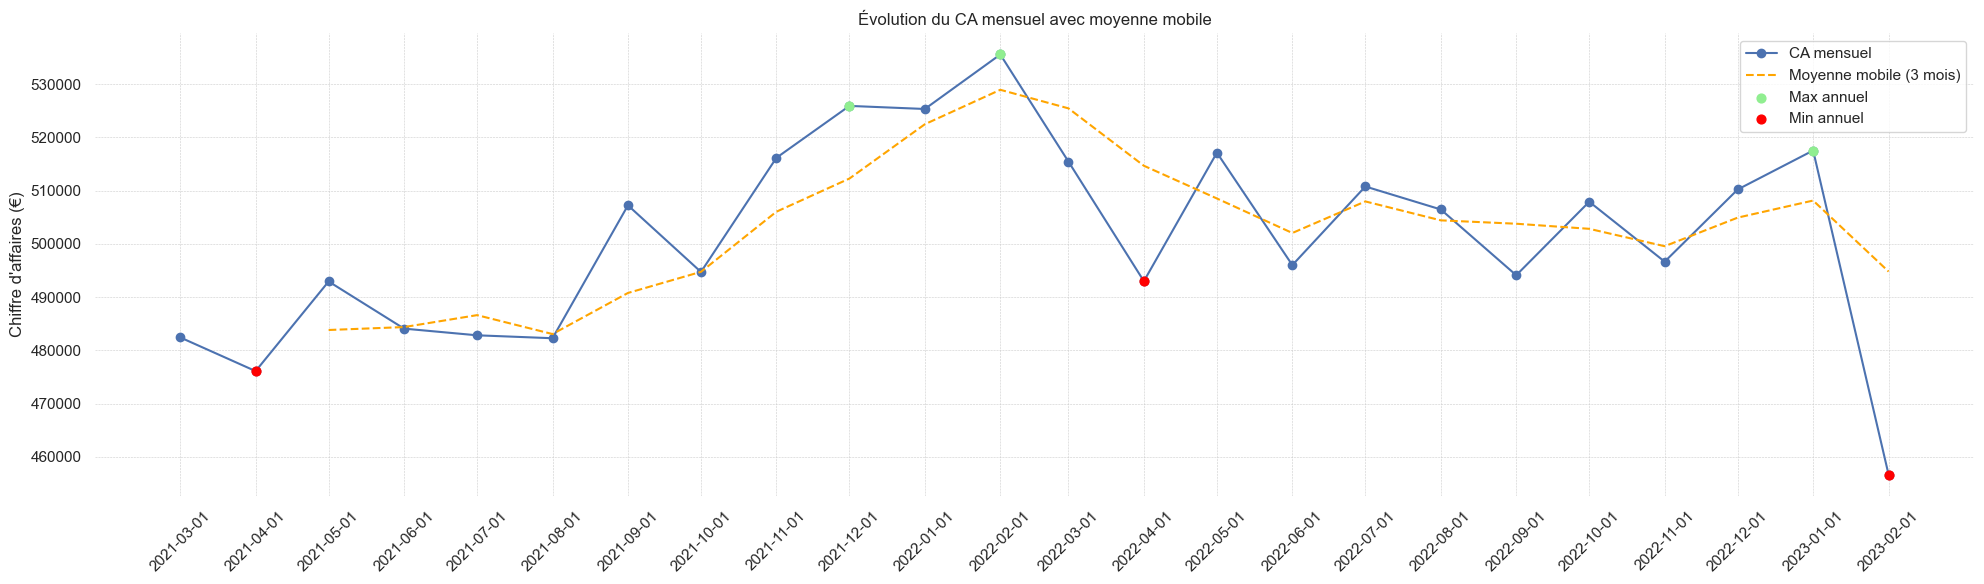

In [82]:
# Conversion en datetime si nécessaire
ca_mensuel['year_month'] = pd.to_datetime(ca_mensuel['year_month'])
ca_mensuel['year'] = ca_mensuel['year_month'].dt.year

# Points max et min par année
max_points = ca_mensuel.loc[ca_mensuel.groupby('year')['price'].idxmax()]
min_points = ca_mensuel.loc[ca_mensuel.groupby('year')['price'].idxmin()]

# Dataviz
plt.figure(figsize=(20, 6))
plt.plot(ca_mensuel['year_month'], ca_mensuel['price'], label='CA mensuel', marker='o')
plt.plot(ca_mensuel['year_month'], ca_mensuel['CA_moyenne_mobile'], label='Moyenne mobile (3 mois)', linestyle='--', color='orange')

# Marqueurs extrêmes
plt.scatter(max_points['year_month'], max_points['price'], color='lightgreen', s=40, label='Max annuel', zorder=5)
plt.scatter(min_points['year_month'], min_points['price'], color='red', s=40, label='Min annuel', zorder=5)

# Affichage complet des dates sur l'axe X
plt.xticks(ticks=ca_mensuel['year_month'], rotation=45)

# Suppression du titre de l'axe X
plt.xlabel('')

plt.ylabel('Chiffre d\'affaires (€)')
plt.title('Évolution du CA mensuel avec moyenne mobile')
plt.legend()

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=0.4, alpha=1)
plt.savefig('ca_moyenne_mobile.png')
plt.show()


<div style="border: 0px solid rgb(51,165,182);">
  <h4 style="margin: auto; padding: 10px; color: rgb(51,165,182);">🟦 CA Quotidien</h4>
</div>

In [84]:
# Création d'une colonne 'year_day' pour l'agrégation quotidienne
df_vf['year_day'] = df_vf['date'].dt.to_period('D').astype(str)

# Agrégation du chiffre d'affaires quotidien
ca_quotidien = df_vf.groupby('year_day')['price'].sum().reset_index()
ca_quotidien['price'] = ca_quotidien['price'].round(2)

# Calcul de la moyenne mobile sur 3 jours
ca_quotidien['CA_moyenne_mobile'] = ca_quotidien['price'].rolling(window=3).mean()
ca_quotidien

,year_day,price,CA_moyenne_mobile
0,2021-03-01,16565.22,NaN
1,2021-03-02,15486.45,NaN
2,2021-03-03,15198.69,15750.120000
3,2021-03-04,15196.07,15293.736667
4,2021-03-05,17471.37,15955.376667
...,...,...,...
725,2023-02-24,15207.89,15418.653333
726,2023-02-25,15761.25,15403.726667
727,2023-02-26,16304.72,15757.953333
728,2023-02-27,19170.81,17078.926667


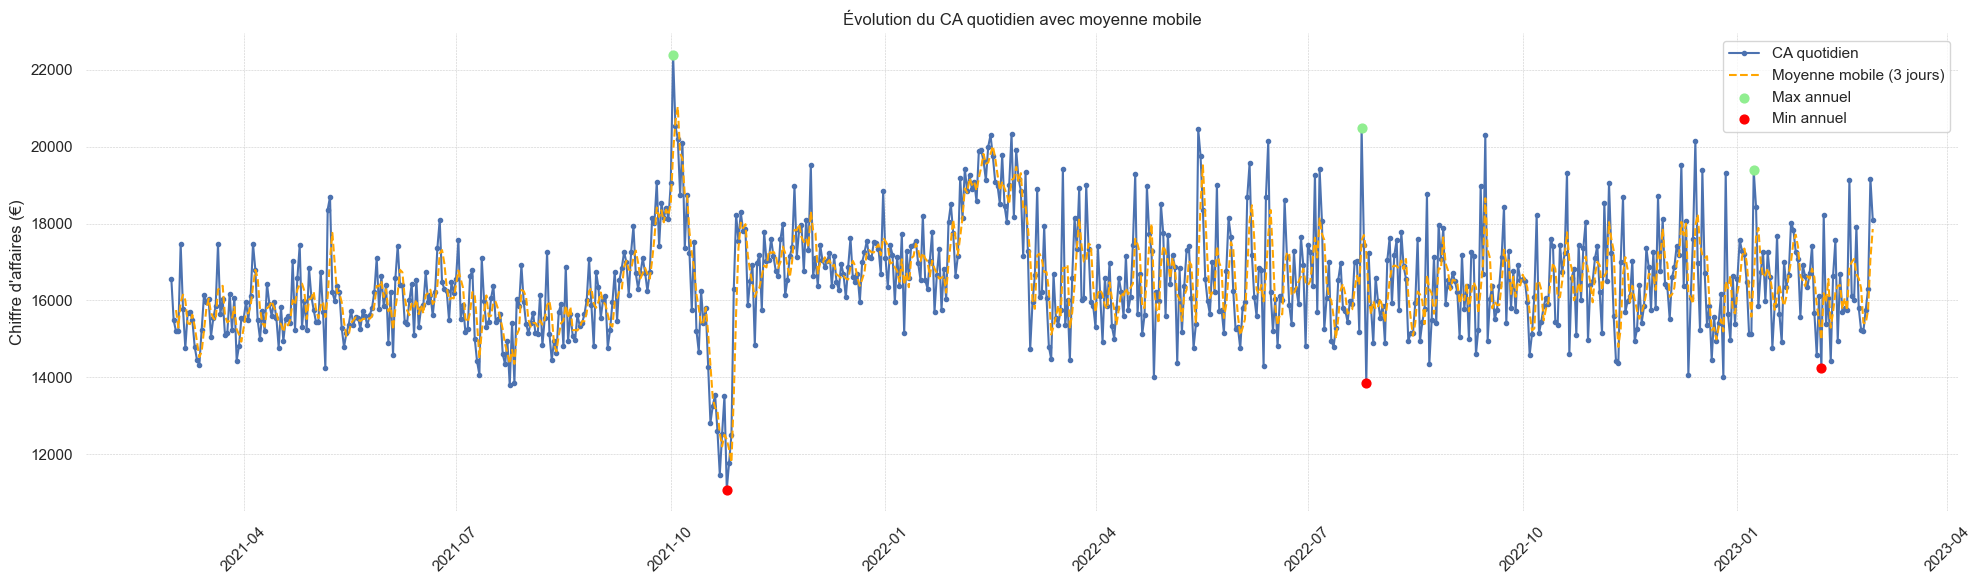

In [85]:
# Conversion en datetime si nécessaire
ca_quotidien['year_day'] = pd.to_datetime(ca_quotidien['year_day'])
ca_quotidien['year'] = ca_quotidien['year_day'].dt.year

# Points max et min par année
max_points = ca_quotidien.loc[ca_quotidien.groupby('year')['price'].idxmax()]
min_points = ca_quotidien.loc[ca_quotidien.groupby('year')['price'].idxmin()]

# Dataviz
plt.figure(figsize=(20, 6))
plt.plot(ca_quotidien['year_day'], ca_quotidien['price'], label='CA quotidien', marker='o', markersize=3)
plt.plot(ca_quotidien['year_day'], ca_quotidien['CA_moyenne_mobile'], label='Moyenne mobile (3 jours)', linestyle='--', color='orange')

# Marqueurs extrêmes
plt.scatter(max_points['year_day'], max_points['price'], color='lightgreen', s=40, label='Max annuel', zorder=5)
plt.scatter(min_points['year_day'], min_points['price'], color='red', s=40, label='Min annuel', zorder=5)

# Affichage complet des dates sur l'axe X (optionnel : espacer les ticks)
plt.xticks(rotation=45)

# Suppression du titre de l'axe X
plt.xlabel('')

plt.ylabel('Chiffre d\'affaires (€)')
plt.title('Évolution du CA quotidien avec moyenne mobile')
plt.legend()

# Esthétique
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=0.4, alpha=1)
plt.savefig('ca_quotidien_moyenne_mobile.png')
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - CA mensuel par catégorie</h3>
</div>

In [87]:
# Agrégation du CA par mois et par catégorie
ca_par_categ = df_vf.groupby(['year_month', 'categ'])['price'].sum().reset_index()
ca_par_categ['price'] = ca_par_categ['price'].round(2)
ca_par_categ

,year_month,categ,price
0,2021-03,0,193629.17
1,2021-03,1,186974.17
2,2021-03,2,101837.27
3,2021-04,0,205222.46
4,2021-04,1,156138.35
...,...,...,...
67,2023-01,1,210104.41
68,2023-01,2,126153.08
69,2023-02,0,162457.00
70,2023-02,1,180347.24


In [88]:
# Pivot pour visualisation
pivot_categ = ca_par_categ.pivot(index='year_month', columns='categ', values='price').fillna(0)
pivot_categ

categ,0,1,2
year_month,,,
2021-03,193629.17,186974.17,101837.27
2021-04,205222.46,156138.35,114748.49
2021-05,196186.72,165893.40,130863.35
2021-06,167943.15,189162.04,126983.37
2021-07,144750.79,188523.27,149561.34
2021-08,167737.62,162991.38,151555.79
2021-09,246353.91,190613.78,70272.99
2021-10,199250.83,207696.74,87785.59
2021-11,155909.56,252910.39,107347.78


<Figure size 1400x700 with 0 Axes>

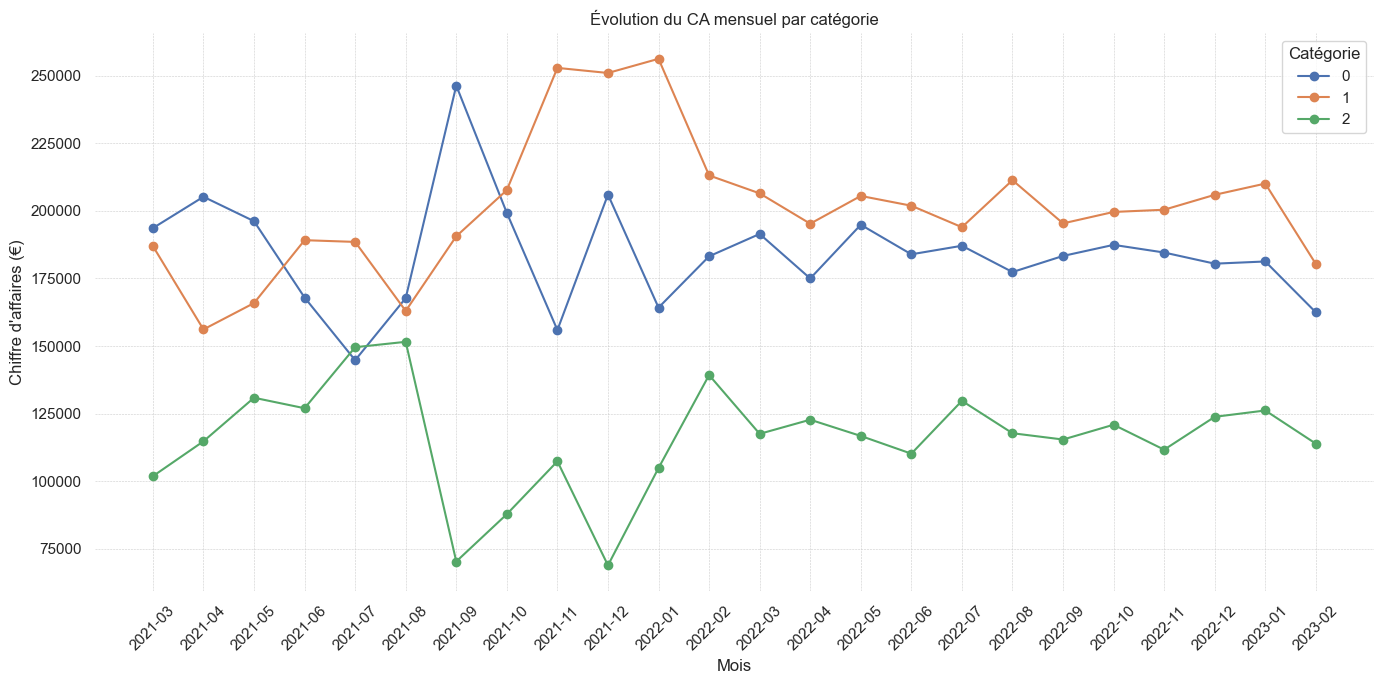

In [89]:
#Dataviz
# Liste complète des mois pour les ticks
mois = pivot_categ.index.tolist()

# Affichage du graphique
plt.figure(figsize=(14, 7))
pivot_categ.plot(kind='line', marker='o', figsize=(14, 7))
plt.title("Évolution du CA mensuel par catégorie")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")
plt.xticks(ticks=range(len(mois)), labels=mois, rotation=45)
plt.grid(True, linestyle='--', linewidth=0.4, alpha=1)
plt.legend(title='Catégorie')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig('ca_par_categorie.png')
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.3 - Nombre de clients par mois</h3>
</div>

In [91]:
# Agrégation du nb de clients par mois
clients_uniques = df_vf.groupby('year_month')['client_id'].nunique()

# Remplacement valeur f/m par Femme/Homme
df_vf['sex'] = df_vf['sex'].replace({'f': 'Femme', 'm': 'Homme'})

# Agrégation par genre
df_id_unique = df_vf.drop_duplicates(subset=['year_month', 'client_id'])
clients_par_sexe = df_id_unique.groupby(['year_month', 'sex'])['client_id'].nunique().unstack(fill_value=0)

# Calcul pourcentage f/m
clients_par_sexe['Total'] = clients_par_sexe.sum(axis=1)
clients_pct = (clients_par_sexe.div(clients_par_sexe['Total'], axis=0) * 100).round(1)

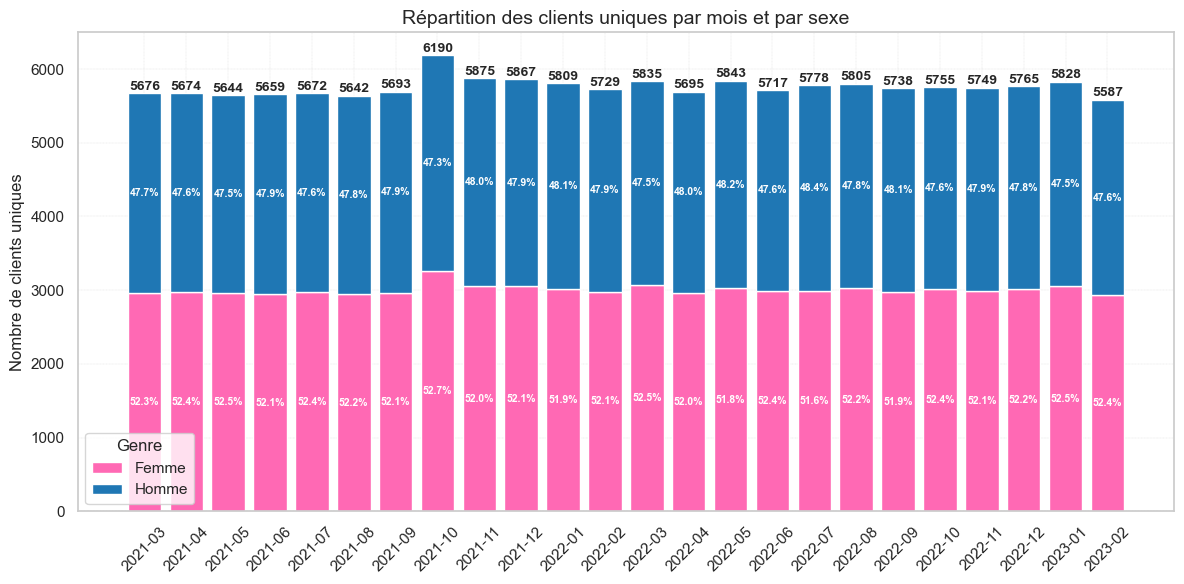

In [92]:
#Dataviz répartition f/m + nb de clients par mois

fig, ax = plt.subplots(figsize=(12, 6))
bottom = None
colors = {'Femme': '#ff69b4', 'Homme': '#1f77b4'}

for sexe in ['Femme', 'Homme']:  # ordre d'empilement
    ax.bar(clients_par_sexe.index, clients_par_sexe[sexe], bottom=bottom, label=sexe, color=colors[sexe])
    
    # Ajout des pourcentages dans la barre
    for i, val in enumerate(clients_par_sexe[sexe]):
        pct = clients_pct[sexe].iloc[i]
        y_pos = val / 2 if bottom is None else bottom.iloc[i] + val / 2
        ax.text(clients_par_sexe.index[i], y_pos, f'{pct:.1f}%', ha='center', va='center', color='white', fontsize=7.5, fontweight='bold')
    
    bottom = clients_par_sexe[sexe] if bottom is None else bottom + clients_par_sexe[sexe]

# Ajout du total au-dessus de chaque barre
for i, total in enumerate(clients_par_sexe['Total']):
    ax.text(clients_par_sexe.index[i], total + 5, f'{total}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Mise en forme
ax.set_title('Répartition des clients uniques par mois et par sexe', fontsize=14)
ax.set_ylabel('Nombre de clients uniques')
ax.set_xlabel('')
ax.legend(title='Genre')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', linewidth=0.2, alpha=1)
plt.tight_layout()
plt.show()


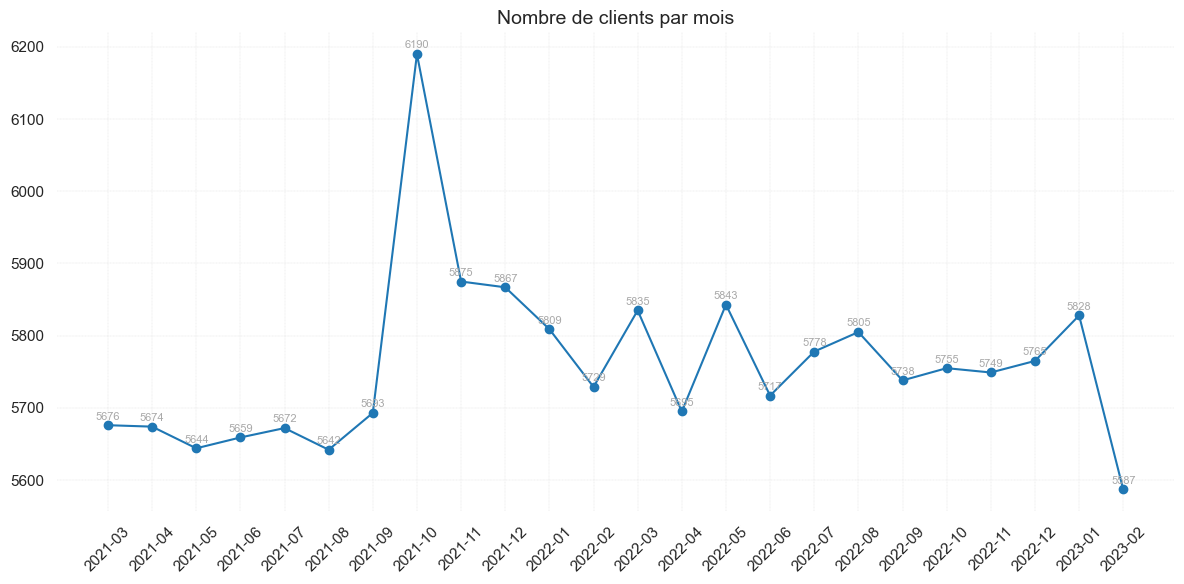

In [93]:
#Dataviz nb de clients par mois
plt.figure(figsize=(12, 6))
plt.plot(clients_uniques.index, clients_uniques.values, marker='o', linestyle='-', color='#1f77b4')

# Ajout des annotations
for i, value in enumerate(clients_uniques.values):
    plt.text(clients_uniques.index[i], value + 5, str(value), ha='center', va='bottom', fontsize=8, color='darkgray')

# Mise en forme
plt.title('Nombre de clients par mois', fontsize=14)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', linewidth=0.2, alpha=1)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.4 - Nombre de transactions par mois</h3>
</div>

In [95]:
# Compter le nombre de transactions (=panier -> session_id) par mois
paniers_par_mois = df_vf.groupby('year_month')['session_id'].nunique()

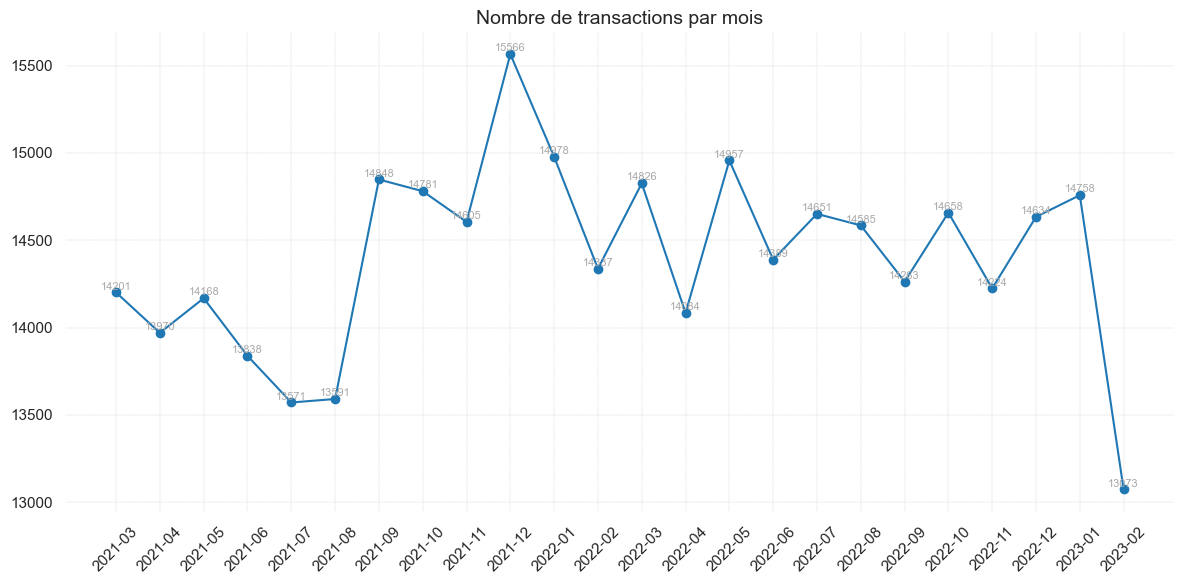

In [96]:
#Dataviz

plt.figure(figsize=(12, 6))
plt.plot(paniers_par_mois.index, paniers_par_mois.values, marker='o', linestyle='-', color='#1f77b4')

# Ajout des annotations au-dessus des marqueurs
for i, value in enumerate(paniers_par_mois.values):
    plt.text(paniers_par_mois.index[i], value + 5, str(value), ha='center', va='bottom', fontsize=8, color='darkgray')

# Mise en forme
plt.title('Nombre de transactions par mois', fontsize=14)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.5 - Nombre de produits vendus par mois</h3>
</div>

In [98]:
# Compter le nombre de produits vendus par mois
prod_par_mois = df_vf.groupby('year_month')['id_prod'].count()

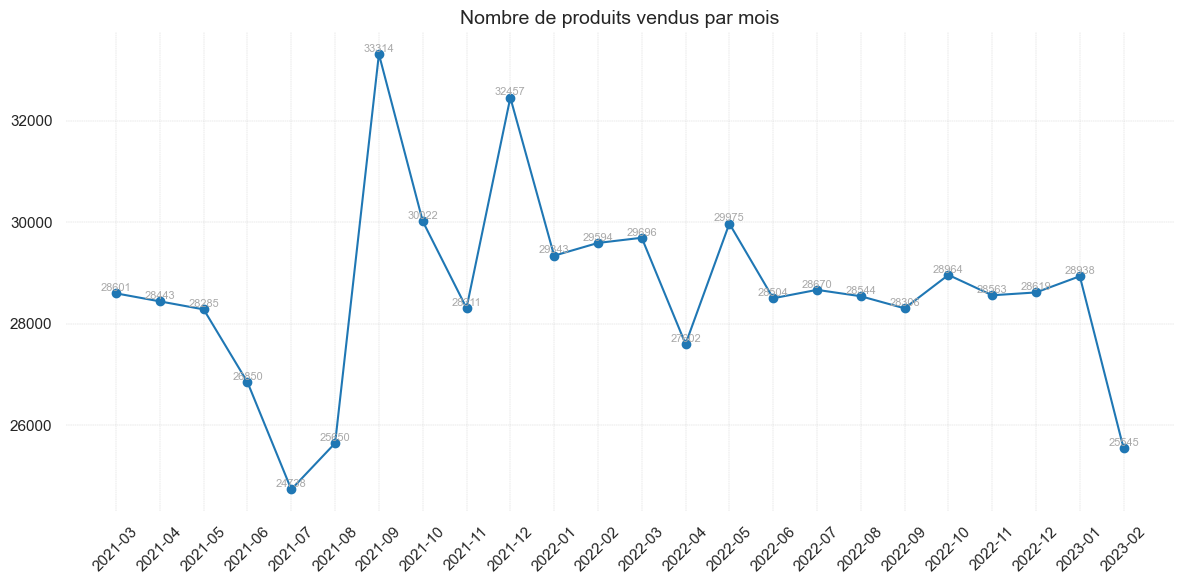

In [99]:
#Dataviz

plt.figure(figsize=(12, 6))
plt.plot(prod_par_mois.index, prod_par_mois.values, marker='o', linestyle='-', color='#1f77b4')

# Ajout des annotations au-dessus des marqueurs
for i, value in enumerate(prod_par_mois.values):
    plt.text(prod_par_mois.index[i], value + 5, str(value), ha='center', va='bottom', fontsize=8, color='darkgray')

# Mise en forme
plt.title('Nombre de produits vendus par mois', fontsize=14)
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.6 - Les tops 10</h3>
</div>

<div style="border: 0px solid rgb(51,165,182);">
  <h4 style="margin: auto; padding: 10px; color: rgb(51,165,182);">🟦 Des références par vente</h4>
</div>


In [102]:
# Toutes catégories confondues
top_10_global = df_vf['id_prod'].value_counts().head(10)
print("Top 10 produits toutes périodes confondues :")
print(top_10_global)

Top 10 produits toutes périodes confondues :
id_prod
1_369    2340
1_417    2269
1_414    2246
1_498    2202
1_425    2163
1_403    2040
1_413    2036
1_412    2014
1_406    2003
1_407    2001
Name: count, dtype: int64


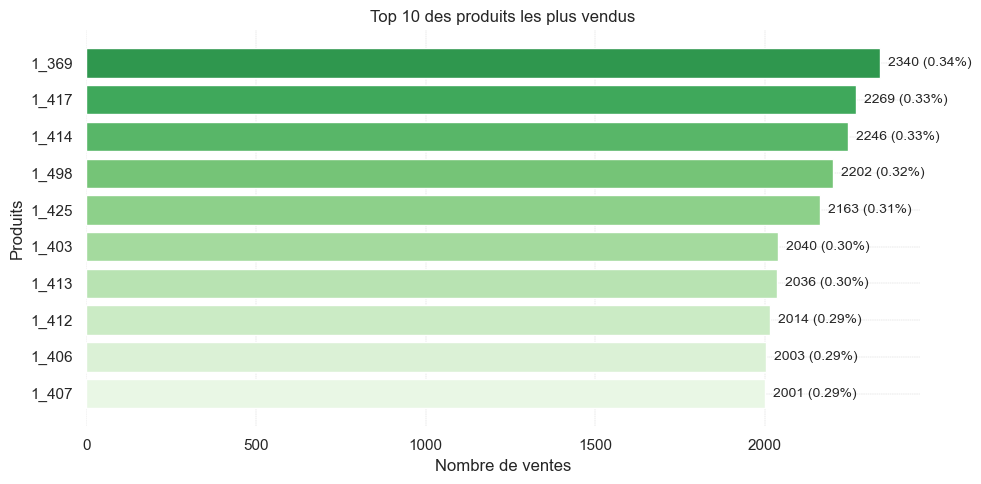

In [103]:
#dataviz
# Total des ventes (toutes lignes de df_vf)
total_ventes = len(df_vf)

# Transformation en DataFrame
df_top10 = top_10_global.reset_index()
df_top10.columns = ['id_prod', 'nb_ventes']

# Calcul du pourcentage
df_top10['pourcentage'] = df_top10['nb_ventes'] / total_ventes * 100

# Création des labels avec 2 décimales
df_top10['label'] = df_top10.apply(
    lambda row: f"{row['nb_ventes']} ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Greens(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_top10['id_prod'], df_top10['nb_ventes'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10['nb_ventes']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus vendu soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Nombre de ventes")
ax.set_ylabel("Produits")
ax.set_title("Top 10 des produits les plus vendus")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

<div style="border: 0px solid rgb(51,165,182);">
  <h4 style="margin: auto; padding: 10px; color: rgb(51,165,182);">🟦 Des références par CA</h4>
</div>

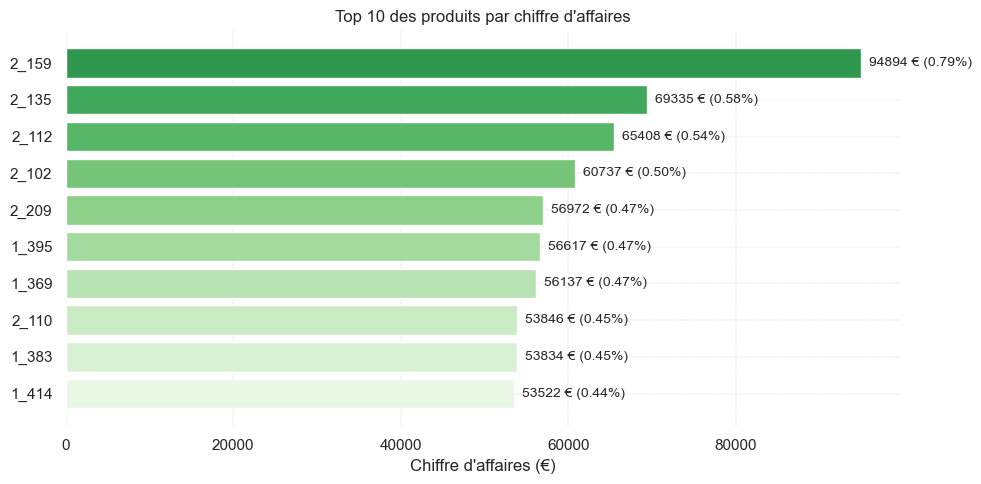

In [105]:
#dataviz
# Top 10 des produits par chiffre d'affaires
top_10_ca = df_vf.groupby('id_prod')['price'].sum().sort_values(ascending=False).head(10)

# Chiffre d'affaires total
total_ca = df_vf['price'].sum()

# Transformation en DataFrame
df_top10_ca = top_10_ca.reset_index()
df_top10_ca.columns = ['id_prod', 'chiffre_affaires']

# Calcul du pourcentage
df_top10_ca['pourcentage'] = df_top10_ca['chiffre_affaires'] / total_ca * 100

# Création des labels avec 2 décimales
df_top10_ca['label'] = df_top10_ca.apply(
    lambda row: f"{row['chiffre_affaires']:.0f} € ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Greens(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_top10_ca['id_prod'], df_top10_ca['chiffre_affaires'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10_ca['chiffre_affaires']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10_ca['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus rentable soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Chiffre d'affaires (€)")
ax.set_title("Top 10 des produits par chiffre d'affaires")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

<div style="border: 0px solid rgb(51,165,182);">
  <h4 style="margin: auto; padding: 10px; color: rgb(51,165,182);">🟦 Par catégorie</h4>
</div>

<div style="border: 0px solid rgb(51,165,182);">
  <h5 style="margin: auto; padding: 10px; color: rgb(51,165,182);">Catégorie 0</h5>
</div>

In [108]:
# Prépa df filtré pour la catégorie 0
df_categ_0 = df_vf[df_vf['categ'] == 0]

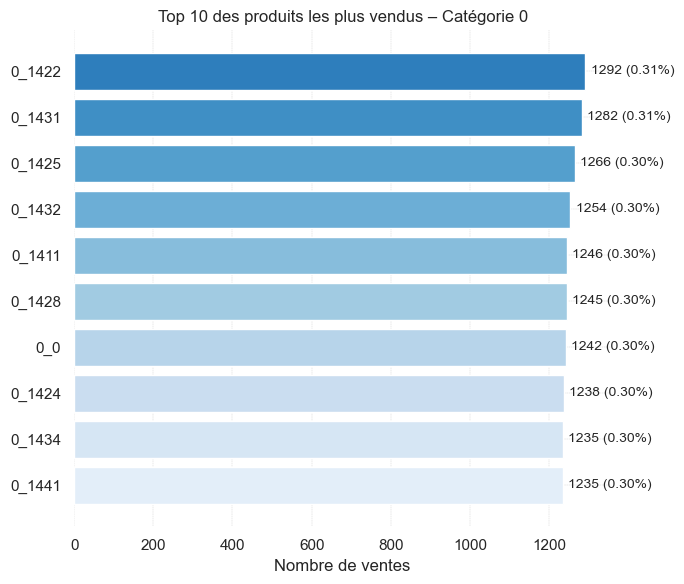

In [109]:
# PAR NB DE REFERENCES VENDUES

# Calcul du top 10 des produits vendus dans cette catégorie
top_10_categ_0 = df_categ_0['id_prod'].value_counts().head(10)

# Total des ventes dans la catégorie 0
total_ventes_categ_0 = len(df_categ_0)

# Transformation en DataFrame
df_top10 = top_10_categ_0.reset_index()
df_top10.columns = ['id_prod', 'nb_ventes']

# Calcul du pourcentage
df_top10['pourcentage'] = df_top10['nb_ventes'] / total_ventes_categ_0 * 100

# Création des labels avec 2 décimales
df_top10['label'] = df_top10.apply(
    lambda row: f"{row['nb_ventes']} ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Blues(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(df_top10['id_prod'], df_top10['nb_ventes'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10['nb_ventes']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus vendu soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Nombre de ventes")
ax.set_title("Top 10 des produits les plus vendus – Catégorie 0")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

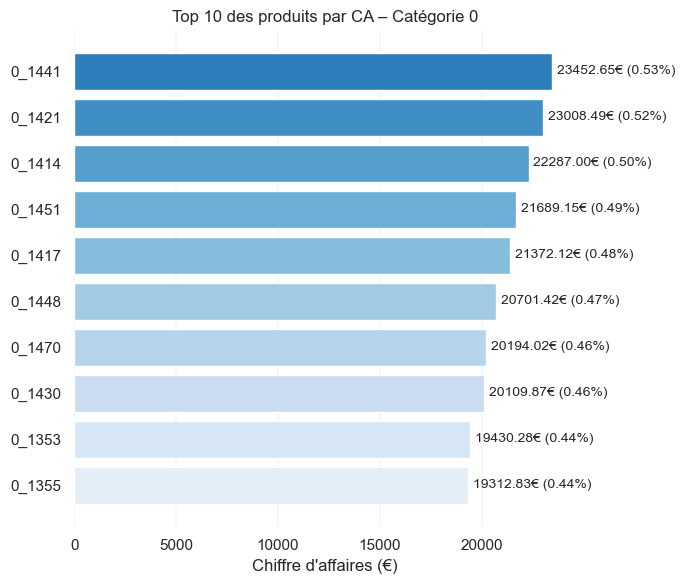

In [110]:
# PAR CA

# Calcul du top 10 des produits par chiffre d'affaires dans cette catégorie
top_10_ca_categ_0 = df_categ_0.groupby('id_prod')['price'].sum().sort_values(ascending=False).head(10)

# Total du CA dans la catégorie 0
total_ca_categ_0 = df_categ_0['price'].sum()

# Transformation en DataFrame
df_top10_0 = top_10_ca_categ_0.reset_index()
df_top10_0.columns = ['id_prod', 'chiffre_affaires']

# Calcul du pourcentage
df_top10_0['pourcentage'] = df_top10_0['chiffre_affaires'] / total_ca_categ_0 * 100

# Création des labels avec 2 décimales
df_top10_0['label'] = df_top10_0.apply(
    lambda row: f"{row['chiffre_affaires']:.2f}€ ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Blues(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(df_top10_0['id_prod'], df_top10_0['chiffre_affaires'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10_0['chiffre_affaires']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10_0['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus vendu soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Chiffre d'affaires (€)")
ax.set_title("Top 10 des produits par CA – Catégorie 0")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

<div style="border: 0px solid rgb(51,165,182);">
  <h5 style="margin: auto; padding: 10px; color: rgb(51,165,182);">Catégorie 1</h5>
</div>

In [112]:
# Prépa df filtré pour la catégorie 1
df_categ_1 = df_vf[df_vf['categ'] == 1]

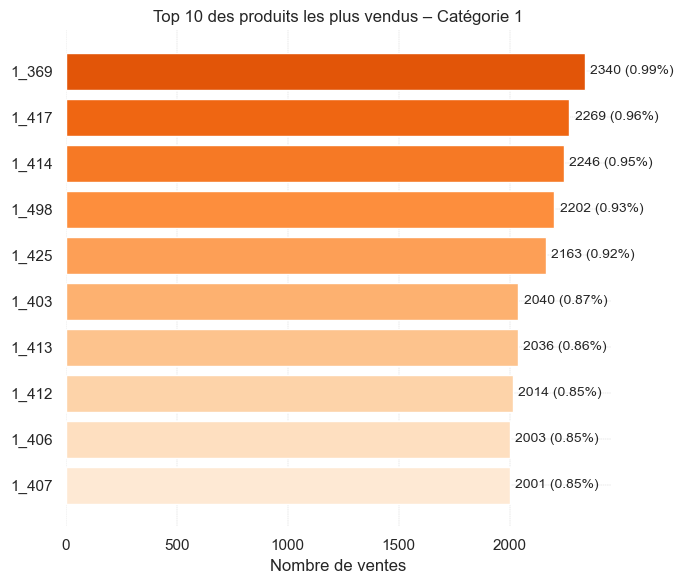

In [113]:
# PAR NB DE REFERENCES VENDUES

# Calcul du top 10 des produits vendus dans cette catégorie
top_10_categ_1 = df_categ_1['id_prod'].value_counts().head(10)

# Total des ventes dans la catégorie 1
total_ventes_categ_1 = len(df_categ_1)

# Transformation en DataFrame
df_top10_1 = top_10_categ_1.reset_index()
df_top10_1.columns = ['id_prod', 'nb_ventes']

# Calcul du pourcentage
df_top10_1['pourcentage'] = df_top10_1['nb_ventes'] / total_ventes_categ_1 * 100

# Création des labels avec 2 décimales
df_top10_1['label'] = df_top10_1.apply(
    lambda row: f"{row['nb_ventes']} ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Oranges(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(df_top10_1['id_prod'], df_top10_1['nb_ventes'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10_1['nb_ventes']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10_1['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus vendu soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Nombre de ventes")
ax.set_title("Top 10 des produits les plus vendus – Catégorie 1")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

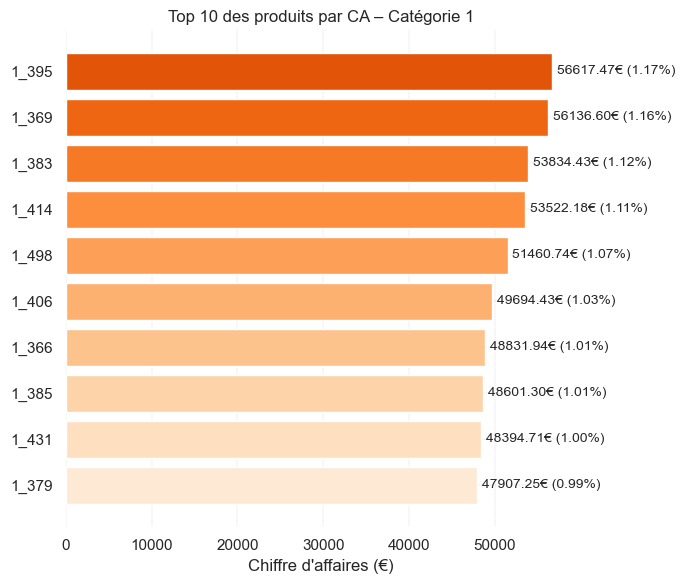

In [114]:
# PAR CA

# Calcul du top 10 des produits par chiffre d'affaires dans cette catégorie
top_10_ca_categ_1 = df_categ_1.groupby('id_prod')['price'].sum().sort_values(ascending=False).head(10)

# Total du CA dans la catégorie 1
total_ca_categ_1 = df_categ_1['price'].sum()

# Transformation en DataFrame
df_top10_2 = top_10_ca_categ_1.reset_index()
df_top10_2.columns = ['id_prod', 'chiffre_affaires']

# Calcul du pourcentage
df_top10_2['pourcentage'] = df_top10_2['chiffre_affaires'] / total_ca_categ_1 * 100

# Création des labels avec 2 décimales
df_top10_2['label'] = df_top10_2.apply(
    lambda row: f"{row['chiffre_affaires']:.2f}€ ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Oranges(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(df_top10_2['id_prod'], df_top10_2['chiffre_affaires'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10_2['chiffre_affaires']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10_2['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus vendu soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Chiffre d'affaires (€)")
ax.set_title("Top 10 des produits par CA – Catégorie 1")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

In [115]:
# Prépa df filtré pour la catégorie 2
df_categ_2 = df_vf[df_vf['categ'] == 2]

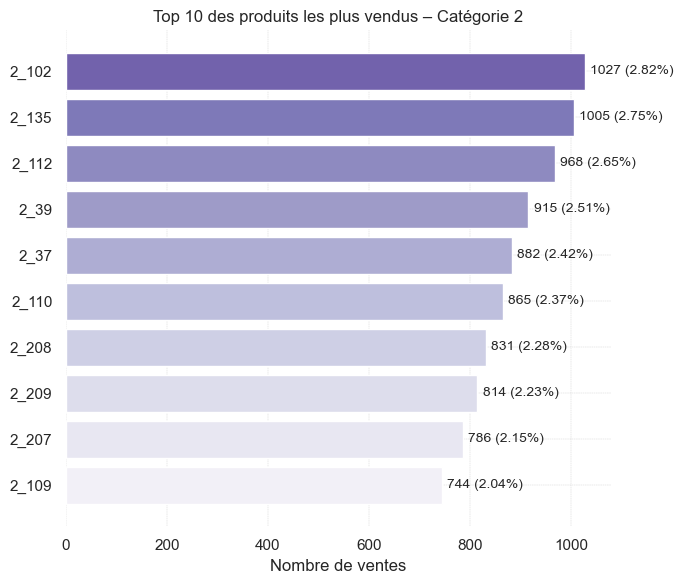

In [116]:
# PAR NB DE REFERENCES VENDUES

# Calcul du top 10 des produits vendus dans cette catégorie
top_10_categ_2 = df_categ_2['id_prod'].value_counts().head(10)

# Total des ventes dans la catégorie 2
total_ventes_categ_2 = len(df_categ_2)

# Transformation en DataFrame
df_top10_3 = top_10_categ_2.reset_index()
df_top10_3.columns = ['id_prod', 'nb_ventes']

# Calcul du pourcentage
df_top10_3['pourcentage'] = df_top10_3['nb_ventes'] / total_ventes_categ_2 * 100

# Création des labels avec 2 décimales
df_top10_3['label'] = df_top10_3.apply(
    lambda row: f"{row['nb_ventes']} ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Purples(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(df_top10_3['id_prod'], df_top10_3['nb_ventes'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10_3['nb_ventes']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10_3['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus vendu soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Nombre de ventes")
ax.set_title("Top 10 des produits les plus vendus – Catégorie 2")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

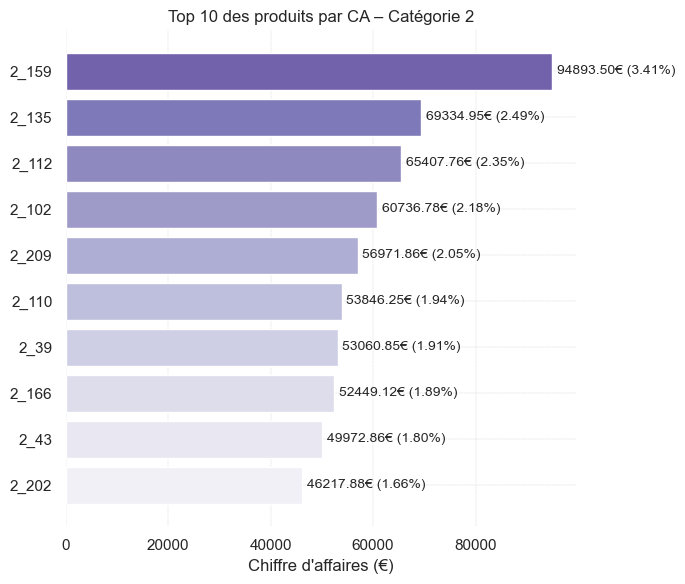

In [117]:
# PAR CA

# Calcul du top 10 des produits par chiffre d'affaires dans cette catégorie
top_10_ca_categ_2 = df_categ_2.groupby('id_prod')['price'].sum().sort_values(ascending=False).head(10)

# Total du CA dans la catégorie 1
total_ca_categ_2 = df_categ_2['price'].sum()

# Transformation en DataFrame
df_top10_5 = top_10_ca_categ_2.reset_index()
df_top10_5.columns = ['id_prod', 'chiffre_affaires']

# Calcul du pourcentage
df_top10_5['pourcentage'] = df_top10_5['chiffre_affaires'] / total_ca_categ_2 * 100

# Création des labels avec 2 décimales
df_top10_5['label'] = df_top10_5.apply(
    lambda row: f"{row['chiffre_affaires']:.2f}€ ({row['pourcentage']:.2f}%)", axis=1
)

# Palette de verts du plus foncé au plus clair
palette_verts = [mcolors.to_hex(c) for c in plt.cm.Purples(np.linspace(0.7, 0.1, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.barh(df_top10_5['id_prod'], df_top10_5['chiffre_affaires'], color=palette_verts)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_top10_5['chiffre_affaires']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_top10_5['label'].iloc[i],
            va='center', fontsize=10)

# Inversion de l'ordre pour que le produit le plus vendu soit en haut
ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Chiffre d'affaires (€)")
ax.set_title("Top 10 des produits par CA – Catégorie 2")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.7 - Les flops 10</h3>
</div>

In [119]:
# Toutes catégories confondues
flop_10_global = df_vf['id_prod'].value_counts().tail(10)
print("Flop 10 produits toutes périodes confondues :")
print(flop_10_global)

Flop 10 produits toutes périodes confondues :
id_prod
0_1539    1
0_1151    1
0_1728    1
2_81      1
0_2201    1
0_549     1
0_886     1
0_1498    1
0_541     1
0_1284    1
Name: count, dtype: int64


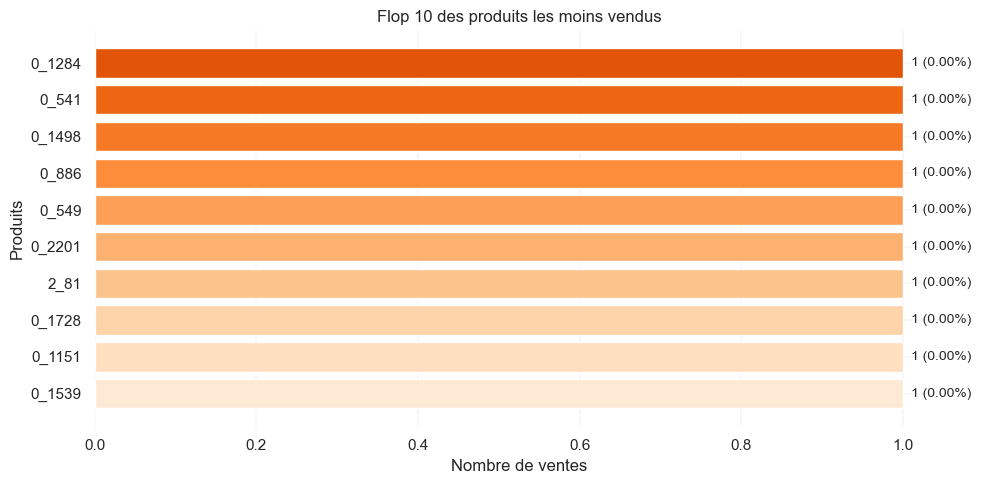

In [120]:
import matplotlib.colors as mcolors

# Total des ventes (toutes lignes de df_vf)
total_ventes = len(df_vf)

# Transformation en DataFrame
df_flop10 = flop_10_global.reset_index()
df_flop10.columns = ['id_prod', 'nb_ventes']

# Calcul du pourcentage
df_flop10['pourcentage'] = df_flop10['nb_ventes'] / total_ventes * 100

# Création des labels avec 2 décimales
df_flop10['label'] = df_flop10.apply(
    lambda row: f"{row['nb_ventes']} ({row['pourcentage']:.2f}%)", axis=1
)

# Palette orangée du plus foncé au plus clair
palette_orange = [mcolors.to_hex(c) for c in plt.cm.Oranges(np.linspace(0.1, 0.7, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_flop10['id_prod'], df_flop10['nb_ventes'], color=palette_orange)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_flop10['nb_ventes']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_flop10['label'].iloc[i],
            va='center', fontsize=10)

# Titres et mise en forme
ax.set_xlabel("Nombre de ventes")
ax.set_ylabel("Produits")
ax.set_title("Flop 10 des produits les moins vendus")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()


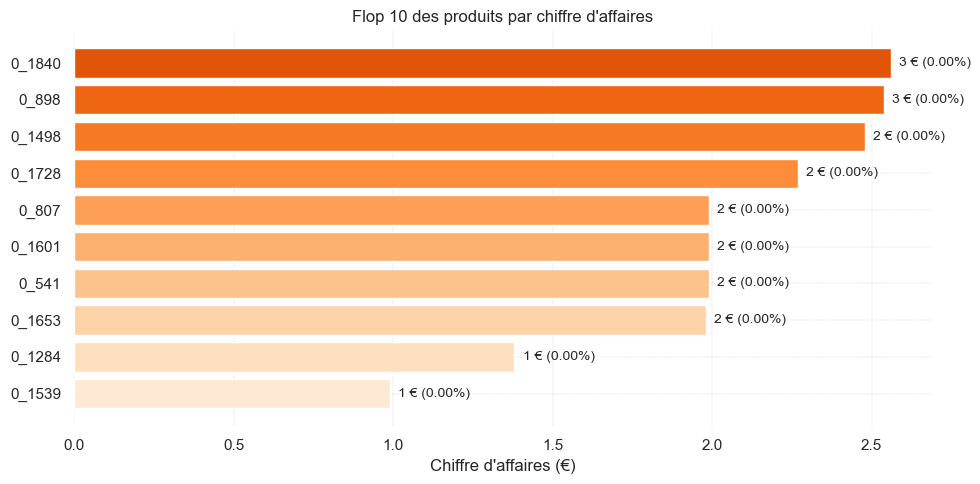

In [121]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

# Flop 10 des produits par chiffre d'affaires
flop_10_ca = df_vf.groupby('id_prod')['price'].sum().sort_values(ascending=True).head(10)

# Chiffre d'affaires total
total_ca = df_vf['price'].sum()

# Transformation en DataFrame
df_flop10_ca = flop_10_ca.reset_index()
df_flop10_ca.columns = ['id_prod', 'chiffre_affaires']

# Calcul du pourcentage
df_flop10_ca['pourcentage'] = df_flop10_ca['chiffre_affaires'] / total_ca * 100

# Création des labels avec 2 décimales
df_flop10_ca['label'] = df_flop10_ca.apply(
    lambda row: f"{row['chiffre_affaires']:.0f} € ({row['pourcentage']:.2f}%)", axis=1
)

# Palette orangée du plus foncé au plus clair
palette_orange = [mcolors.to_hex(c) for c in plt.cm.Oranges(np.linspace(0.1, 0.7, 10))]

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_flop10_ca['id_prod'], df_flop10_ca['chiffre_affaires'], color=palette_orange)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Ajout des labels à droite des barres
for i, bar in enumerate(bars):
    ax.text(bar.get_width() + max(df_flop10_ca['chiffre_affaires']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            df_flop10_ca['label'].iloc[i],
            va='center', fontsize=10)

# Ici, pas besoin d'inverser l'ordre : on veut voir le moins rentable en haut
# Si tu veux garder la cohérence visuelle avec le top (barre la plus claire en bas),
# tu peux activer : ax.invert_yaxis()

# Titres et mise en forme
ax.set_xlabel("Chiffre d'affaires (€)")
ax.set_title("Flop 10 des produits par chiffre d'affaires")
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.8 - Répartition par catégorie</h3>
</div>

In [123]:
# PAR NOMBRE DE VENTES
repartition_nb = df_vf['categ'].value_counts().reset_index()
repartition_nb.columns = ['categ', 'nb_ventes']
repartition_nb['pourcentage'] = repartition_nb['nb_ventes'] / len(df_vf) * 100

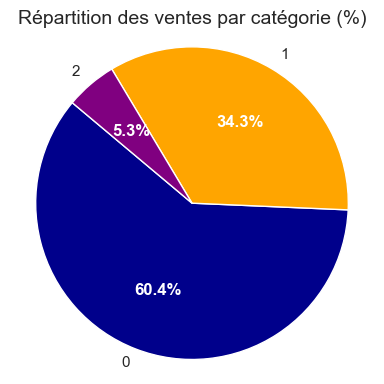

In [124]:
# dataviz camembert
# Définir les couleurs par catégorie
couleurs = {0: 'darkblue', 1: 'orange', 2: 'purple'}
colors = [couleurs[c] for c in repartition_nb['categ']]

# Fonction pour afficher les pourcentages en blanc
def make_autopct_white():
    def autopct(pct):
        return f'{pct:.1f}%' if pct > 0 else ''
    return lambda pct: f'{autopct(pct)}'

# Création du camembert
plt.figure(figsize=(4, 4))
wedges, texts, autotexts = plt.pie(
    repartition_nb['pourcentage'],
    labels=repartition_nb['categ'],
    autopct=make_autopct_white(),
    startangle=140,
    colors=colors  # Couleurs personnalisées ici
)

# Appliquer la couleur blanche aux textes de pourcentage
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title("Répartition des ventes par catégorie (%)", fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()



In [125]:
# PAR CA
repartition_ca = df_vf.groupby('categ')['price'].sum().reset_index()
repartition_ca.columns = ['categ', 'chiffre_affaires']
repartition_ca['pourcentage'] = repartition_ca['chiffre_affaires'] / df_vf['price'].sum() * 100

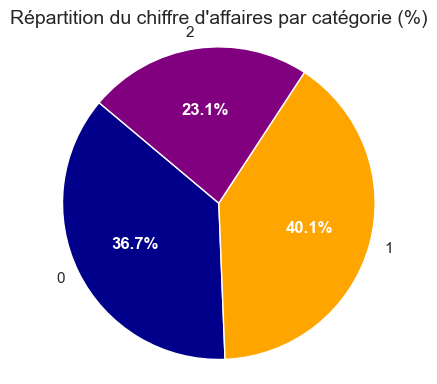

In [126]:
#dataviz camembert
# Couleurs personnalisées par catégorie
couleurs = {0: 'darkblue', 1: 'orange', 2: 'purple'}
colors = [couleurs[c] for c in repartition_ca['categ']]

# Fonction pour formater les pourcentages
def make_autopct_white():
    def autopct(pct):
        return f'{pct:.1f}%' if pct > 0 else ''
    return lambda pct: f'{autopct(pct)}'

# Création du camembert
plt.figure(figsize=(4, 4))
wedges, texts, autotexts = plt.pie(
    repartition_ca['pourcentage'],
    labels=repartition_ca['categ'],
    autopct=make_autopct_white(),
    startangle=140,
    colors=colors
)

# Style des pourcentages en blanc
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title("Répartition du chiffre d'affaires par catégorie (%)", fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyses des clients</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Répartition du CA pour les clients BtoB</h3>
</div>

<div style="border: 0px solid rgb(51,165,182);">
  <h4 style="margin: auto; padding: 10px; color: rgb(51,165,182);">🟦 Identification des clients BtoB</h4>
</div>

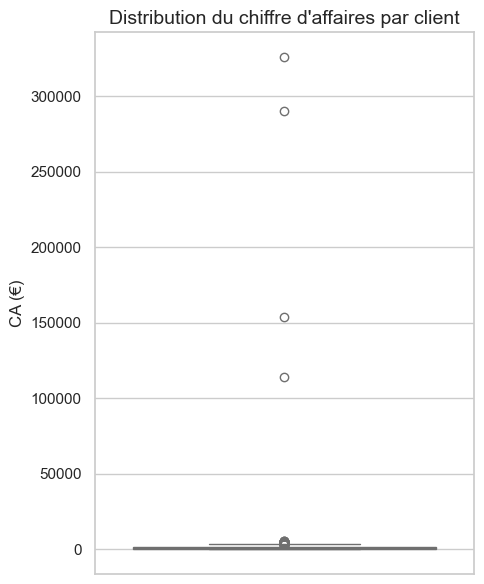

In [130]:
# 1. Calcul du CA par client (df dédié ca_clients)
ca_clients = df_vf.groupby('client_id')['price'].sum().reset_index()
ca_clients.columns = ['client_id', 'CA_total']

# 2. Visualisation des outliers (VISUALISATION BOXPLOT)
plt.figure(figsize=(5, 6))
sns.boxplot(data=ca_clients, y='CA_total', color='skyblue')

plt.title("Distribution du chiffre d'affaires par client", fontsize=14)
plt.ylabel("CA (€)")
plt.xlabel("")
plt.tight_layout()
plt.show()

<span style="background-color: yellow">En se basasant sur le graphique, 4 outliers se détachent. Déduction : les B2B représentent un CA > 100k euros</span>

In [132]:
# Filtrer les clients dont le CA dépasse 100 000 €
clients_b2b = ca_clients[ca_clients['CA_total'] > 100000].sort_values('CA_total', ascending=False)

# Calcul du CA total des clients B2B
total_b2b = clients_b2b['CA_total'].sum()

# Ajout d'une colonne 'pct_CA' avec le pourcentage
clients_b2b['%_CA'] = (clients_b2b['CA_total'] / clients_b2b['CA_total'].sum() * 100).round(0).astype(int).astype(str) + '%'
clients_b2b

,client_id,CA_total,%_CA
677,c_1609,326039.89,37%
4388,c_4958,290227.03,33%
6337,c_6714,153918.60,17%
2724,c_3454,114110.57,13%


In [133]:
# Prépa df pour analyse
# 1. Création col B2B dans df principal pour identifier ces clients
df_vf['type_client'] = df_vf['client_id'].isin(clients_b2b['client_id'])

In [134]:
# 2. Extraction transactions BtoB
df_b2b = df_vf[df_vf['type_client']]
df_b2b

,id_prod,date,session_id,client_id,annee,mois,jour,jour_lettre,mois_lettre,price,categ,sex,birth,Age,year_month,year_day,type_client
7,0_0,2021-03-10 06:43:31.234015,s_4266,c_6714,2021.0,3.0,10.0,Mercredi,Mars,3.75,0,Femme,1968,57,2021-03,2021-03-10,True
9,0_0,2021-03-10 15:40:09.343729,s_4428,c_6714,2021.0,3.0,10.0,Mercredi,Mars,3.75,0,Femme,1968,57,2021-03,2021-03-10,True
31,0_0,2021-03-22 23:37:09.874830,s_10114,c_1609,2021.0,3.0,22.0,Lundi,Mars,3.75,0,Homme,1980,45,2021-03,2021-03-22,True
54,0_0,2021-04-08 15:29:10.605154,s_17758,c_1609,2021.0,4.0,8.0,Jeudi,Avril,3.75,0,Homme,1980,45,2021-04,2021-04-08,True
79,0_0,2021-04-17 20:09:37.561114,s_21987,c_1609,2021.0,4.0,17.0,Samedi,Avril,3.75,0,Homme,1980,45,2021-04,2021-04-17,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687489,2_96,2023-02-07 10:49:20.233426,s_338157,c_4958,2023.0,2.0,7.0,Mardi,Février,47.91,2,Homme,1999,26,2023-02,2023-02-07,True
687502,2_96,2023-02-21 04:43:48.843506,s_344668,c_6714,2023.0,2.0,21.0,Mardi,Février,47.91,2,Femme,1968,57,2023-02,2023-02-21,True
687503,2_96,2023-02-21 20:23:52.060094,s_344997,c_4958,2023.0,2.0,21.0,Mardi,Février,47.91,2,Homme,1999,26,2023-02,2023-02-21,True
687514,2_97,2021-06-12 06:27:05.794886,s_47520,c_4958,2021.0,6.0,12.0,Samedi,Juin,160.99,2,Homme,1999,26,2021-06,2021-06-12,True


<div style="border: 0px solid rgb(51,165,182);">
  <h4 style="margin: auto; padding: 10px; color: rgb(51,165,182);">🟦 Répartition du CA par client et par catégorie</h4>
</div>

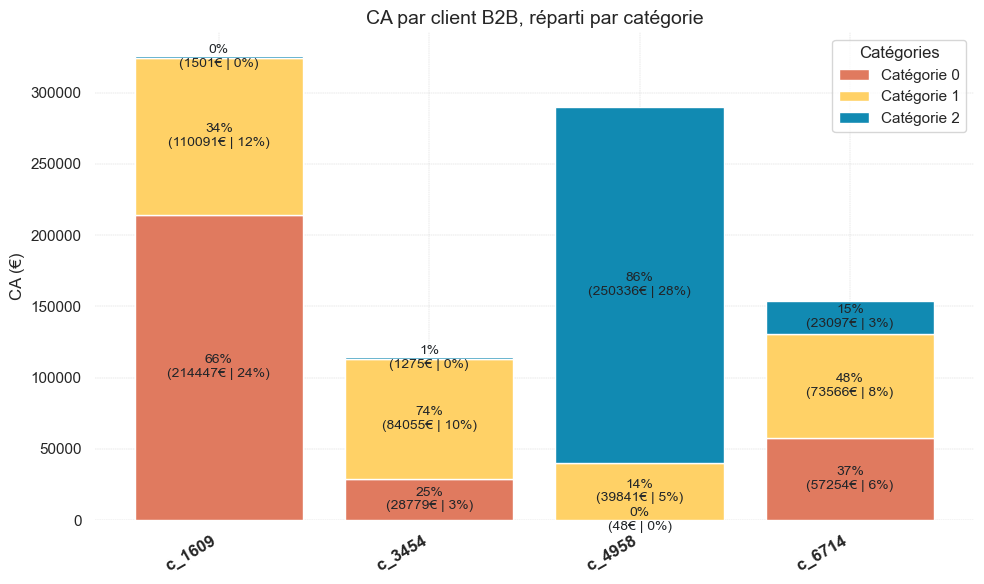

In [136]:
# Agrégation du CA par client et catégorie
df_grouped = df_b2b.groupby(['client_id', 'categ'])['price'].sum().reset_index()

# Pivot pour barres empilées
df_pivot = df_grouped.pivot(index='client_id', columns='categ', values='price').fillna(0)

# CA total par client
ca_client = df_pivot.sum(axis=1)

# CA total global
ca_global = ca_client.sum()

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = range(len(df_pivot.index))
bottom = [0] * len(df_pivot)

# Suppression du cadre (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

colors = {0: '#e07a5f', 1: '#ffd166', 2: '#118ab2'}  # couleurs personnalisées

for cat in sorted(df_pivot.columns):
    bars = ax.bar(x_pos, df_pivot[cat], bottom=bottom, label=f'Catégorie {cat}', color=colors[cat])
    
    # Ajout du double affichage dans chaque segment
    for i, bar in enumerate(bars):
        val = df_pivot.iloc[i][cat]
        if val > 0:
            pct_client = round(val / ca_client.iloc[i] * 100)
            pct_global = round(val / ca_global * 100)
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{pct_client}%\n({int(val)}€ | {pct_global}%)",
                    ha='center', va='center',
                    color='#212529', fontsize=10, fontweight='normal')
    
    bottom = [i + j for i, j in zip(bottom, df_pivot[cat])]

# Axe X
ax.set_xticks(x_pos)
ax.set_xticklabels(df_pivot.index, rotation=30, ha='right', fontsize=12, fontweight='bold')

# Personnalisation
ax.set_ylabel("CA (€)", fontsize=12)
ax.set_title("CA par client B2B, réparti par catégorie", fontsize=14)
ax.legend(title="Catégories", loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.3, alpha=1)
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Courbe de Lorenz pour les particuliers</h3>
</div>

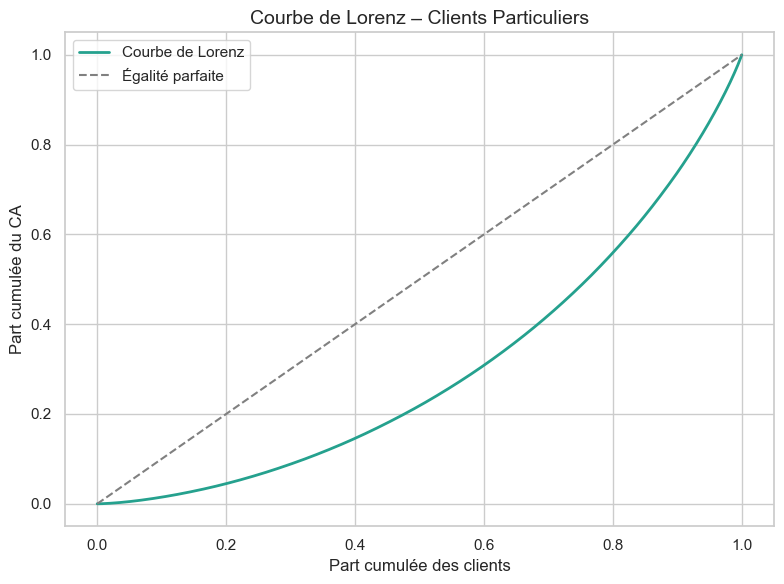

In [138]:
# Étape 1 : filtrer les clients particuliers
clients_particuliers = df_vf[~df_vf['client_id'].isin(clients_b2b['client_id'])]

# Étape 2 : calcul du CA total par client particulier
ca_particuliers = clients_particuliers.groupby('client_id')['price'].sum().reset_index()
ca_particuliers = ca_particuliers.sort_values('price')  # tri croissant

# Étape 3 : calcul des parts cumulées
ca_values = ca_particuliers['price'].values
ca_total = ca_values.sum()
ca_cum = np.cumsum(ca_values) / ca_total
clients_cum = np.arange(1, len(ca_values)+1) / len(ca_values)

# Étape 4 : ajout du point (0,0)
ca_cum = np.insert(ca_cum, 0, 0)
clients_cum = np.insert(clients_cum, 0, 0)

# Étape 5 : tracé de la courbe
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(clients_cum, ca_cum, label='Courbe de Lorenz', color='#25a18e', linewidth=2)
ax.plot([0, 1], [0, 1], label='Égalité parfaite', color='gray', linestyle='--')

# Personnalisation
ax.set_title("Courbe de Lorenz – Clients Particuliers", fontsize=14)
ax.set_xlabel("Part cumulée des clients", fontsize=12)
ax.set_ylabel("Part cumulée du CA", fontsize=12)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

Courbe de Lorenz :
- sert à mesure la répartition des ressources (ici le CA) entre des individus (ici les clients)
- La diagonale grise ("égalité parfaite") correspond à une situation où chaque client contribue exactement de manière proportionnelle : par ex. 20% des clients = 20% du CA.

Analyse :
- la courbe est en dessous de la diagonale -> inégalité de contribution au CA : une majorité de clients contribue peu au CA (donc une minorité contribue bcp)
- Quand on est vers 40% des clients (en bas sur l’axe des x), on est seulement vers 15–20% du CA (axe des y).
- Cela veut dire que 40% des plus petits clients n’apportent qu’environ 20% du revenu.
- Symétriquement, donc, une minorité de clients (les 20% les plus gros) génèrent la majorité du CA (effet Pareto 80/20).

La courbe montre une forte concentration du CA sur une minorité de clients.
C’est une situation très classique en commerce, qui se rapproche de la règle du Pareto (80/20) : 20% des clients font environ 80% du CA.

Recommandations :
- Stratégie marketing : plus d’efforts à mettre sur la fidélisation de ces clients stratégiques.
- Gestion des petits clients : réfléchir à leur potentiel (cross-selling, upselling) ou voir s’ils coûtent plus qu’ils ne rapportent (Un client peut coûter plus qu’il ne rapporte si les coûts de logistique, d’acquisition et de service dépassent sa contribution au chiffre d’affaires.).

Analyses complémentaires :
- Métrique associée : indice de Gini (surface entre la courbe de Lorenz et la ligne d’égalité, divisée par la surface totale sous la ligne d’égalité.)
0=égalité parfaite (tout le monde a la même part) / 1= inégalité totale


In [143]:
#Indice de Gini -> calcule l'aire entre la courbe et la diagonale
def gini(array):
    array = np.sort(array)
    n = len(array)
    cumvals = np.cumsum(array)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

gini_index = gini(ca_values)
print(f"Coefficient de Gini : {gini_index:.2f}")


Coefficient de Gini : 0.40


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse des corrélations</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.1- Genre des clients et catégories des livres achetés</h3>
</div>

1. Formulation des hypothèses
- H0 : le genre du client et la catégorie du livre acheté sont indépendants (pas de lien).
- H1 : le genre du client et la catégorie du livre acheté sont associés (il y a un lien).

2. Choix du test :
Comme les deux variables sont catégorielles (quali/quali), on utilise :
- Test du Chi² d’indépendance -> détermine s'il y a une relation mais pas sa force. Va servir à calculer la p-value. Si p-value>0.05 alors on garde H0. Si p-value<0.05, on rejette H0.
- pour mesurer la force de l’association, calculer le V de Cramer -> détermine la force de la relation

3. Visualisation
- Tableau de contingence (pd.crosstab)
- Graphique nuage de points (scatter plot)

In [147]:
from scipy.stats import chi2_contingency

# 1. Tableau de contingence
contingence = pd.crosstab(df_vf['sex'], df_vf['categ'])
print("Tableau de contingence :\n", contingence)

# 2. Test du Chi² d'indépendance
chi2, p, dof, expected = chi2_contingency(contingence)
print(f"\nTest du Chi² :")
print(f"Chi² = {chi2:.2f}")
print(f"p-value = {p:.4f}")
print(f"Degrés de liberté = {dof}")

# 3. Interprétation de l'hypothèse
if p < 0.05:
    print("On rejette H0 : association significative entre le genre et la catégorie achetée")
else:
    print("On ne rejette pas H0 : pas de preuve de lien significatif")

# 4. V de Cramer (force de l'association)
n = contingence.to_numpy().sum()
phi2 = chi2 / n
r, k = contingence.shape
cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))
print(f"\n📐 V de Cramer = {cramers_v:.3f} (force de l'association)")

Tableau de contingence :
 categ       0       1      2
sex                         
Femme  206103  119307  17283
Homme  209356  116285  19200

Test du Chi² :
Chi² = 158.25
p-value = 0.0000
Degrés de liberté = 2
On rejette H0 : association significative entre le genre et la catégorie achetée

📐 V de Cramer = 0.015 (force de l'association)


La p-value est nettement inférieure à 0.05. Il y a donc un lien entre ces 2 variables.
Par contre, le V de cramer (0.015) montre que cette relation n'est pas forte -> donc pas structurant dans les comportements d'achats

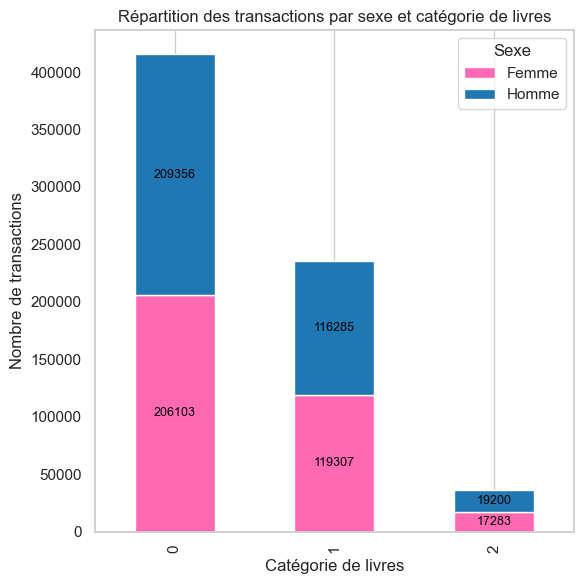

In [149]:
# Étape 1 : Comptage des transactions par sexe et catégorie
df_counts = df_vf.groupby(['categ', 'sex']).size().unstack(fill_value=0)

# Étape 2 : Définir les couleurs personnalisées
custom_colors = {'Femme': '#ff69b4', 'Homme': '#1f77b4'}

# Étape 3 : Tracé des barres empilées
ax = df_counts.plot(kind='bar', stacked=True, figsize=(6, 6), color=[custom_colors[sex] for sex in df_counts.columns])

# Étape 4 : Ajout des annotations
for idx, row in df_counts.iterrows():
    y_offset = 0
    for sex in df_counts.columns:
        count = row[sex]
        if count > 0:
            ax.text(
                x=idx,
                y=y_offset + count / 2,
                s=str(count),
                ha='center',
                va='center',
                fontsize=9,
                color='black'
            )
            y_offset += count

# Personnalisation
plt.title("Répartition des transactions par sexe et catégorie de livres")
plt.xlabel("Catégorie de livres")
plt.ylabel("Nombre de transactions")
plt.legend(title="Sexe")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.2 - Âge des clients et montant total des achats</h3>
</div>

1. Formulation des hypothèses
- H0 : Il n’y a pas de relation linéaire entre l’âge du client et le montant des achats.
- H1 : Il y a une relation linéaire significative entre l’âge du client et le montant des achats.

2. Choix du test :
 Comme les deux variables sont quantitatives, on utilise :
- Coefficient de corrélation de Pearson (r) → mesure la force et la direction de la relation linéaire.
- p-value associée à r → permet de savoir si cette relation est statistiquement significative.
- Si p < 0.05 → on rejette H0 → il y a un lien significatif.
- Si p ≥ 0.05 → on ne rejette pas H0 → pas de preuve suffisante d’un lien.

3. Visualisation recommandée
Pour ce type d’analyse, le nuage de points (scatter plot) est parfaitement adapté :
- Il permet de visualiser la tendance entre les deux variables.
- On peut y ajouter une droite de régression linéaire pour illustrer la corrélation.


📈 Coefficient de corrélation de Pearson : -0.207
p-value : 0.0000
On rejette H0 : il existe une relation linéaire significative entre l'âge et le montant des achats.


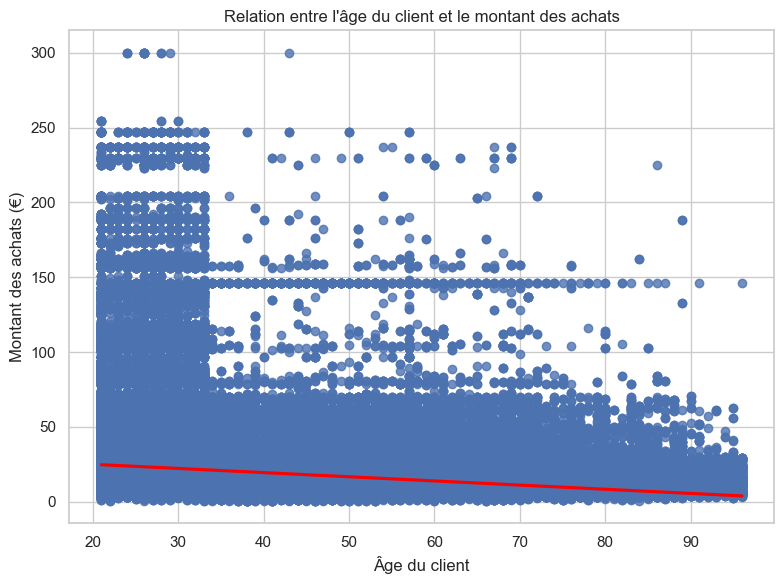

In [152]:
# 1. Filtrage des données valides
df_corr = df_vf[['Age', 'price']].dropna()

# 2. Calcul du coefficient de corrélation de Pearson et de la p-value
r, p_value = pearsonr(df_corr['Age'], df_corr['price'])
print(f"📈 Coefficient de corrélation de Pearson : {r:.3f}")
print(f"p-value : {p_value:.4f}")

# 3. Interprétation
if p_value < 0.05:
    print("On rejette H0 : il existe une relation linéaire significative entre l'âge et le montant des achats.")
else:
    print("On ne rejette pas H0 : pas de preuve suffisante d'une relation linéaire.")

# 4. Visualisation : scatter plot avec droite de régression
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='price', data=df_corr, ci=None, line_kws={"color": "red"})
plt.title("Relation entre l'âge du client et le montant des achats")
plt.xlabel("Âge du client")
plt.ylabel("Montant des achats (€)")
plt.grid(True)
plt.tight_layout()
plt.show()

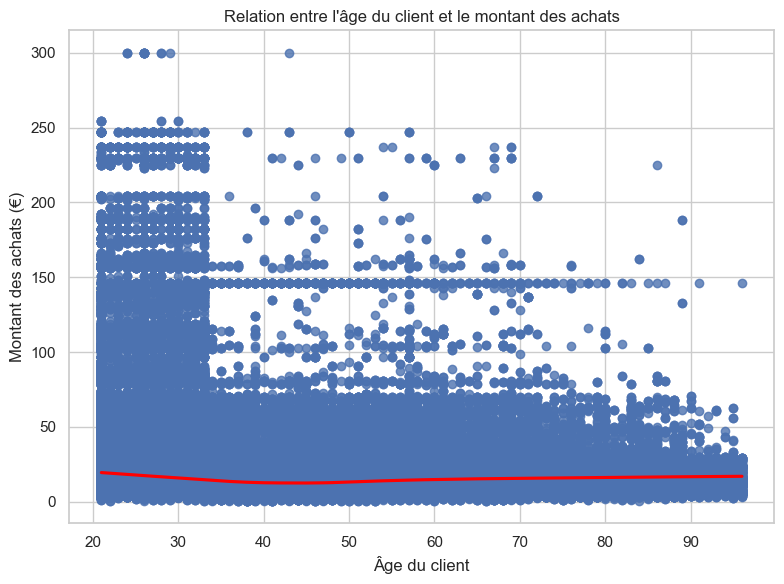

In [153]:
# 4. Visualisation : scatter plot avec lissage local (check spearman)
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='price', data=df_corr, ci=None, line_kws={"color": "red"}, lowess=True)
plt.title("Relation entre l'âge du client et le montant des achats")
plt.xlabel("Âge du client")
plt.ylabel("Montant des achats (€)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [154]:
from scipy.stats import spearmanr

r_spearman, p_spearman = spearmanr(df_corr['Age'], df_corr['price'])
print(f"🔁 Coefficient de Spearman : {r_spearman:.3f}")
print(f"p-value : {p_spearman:.4f}")

🔁 Coefficient de Spearman : -0.055
p-value : 0.0000


Corrélation négative : r = -0.207
- Le coefficient de Pearson est négatif, ce qui signifie que plus l’âge augmente, plus le montant des achats tend à diminuer.
- La valeur -0.207 indique une corrélation faible, mais non négligeable. Ce n’est pas une relation forte, mais elle est suffisamment marquée pour être détectée statistiquement.

p-value = 0.0000
- La p-value est extrêmement faible, bien en dessous du seuil de 0.05.
- Cela signifie que la probabilité que cette corrélation soit due au hasard est quasi nulle.
- Donc, on rejette l’hypothèse nulle (H0) : il y a bien une relation linéaire significative entre l’âge et le montant des achats


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.3 - Âge des clients et fréquence d'achat</h3>
</div>

1. Formulation des hypothèses
- H0 (hypothèse nulle) : Il n’y a pas de relation linéaire entre l’âge du client (age) et le montant des achats (montant_achats).
- H1 (hypothèse alternative) : Il y a une relation linéaire significative entre l’âge du client et le montant des achats.

2. Choix du test statistique :
Comme les deux variables sont quantitatives, on utilise :
- Le coefficient de corrélation de Pearson (r) :
Il mesure la force et la direction de la relation linéaire.
Il varie entre -1 (corrélation négative parfaite) et +1 (corrélation positive parfaite).

- La p-value associée :
- Elle indique si la corrélation est statistiquement significative.
- Seuil de décision :
- Si p < 0.05 → on rejette H0 → il y a un lien significatif.
- Si p ≥ 0.05 → on ne rejette pas H0 → pas de preuve suffisante d’un lien


📈 Coefficient de corrélation de Pearson : 0.007
p-value : 0.5353
On ne rejette pas H0 : pas de preuve suffisante d'une relation linéaire.


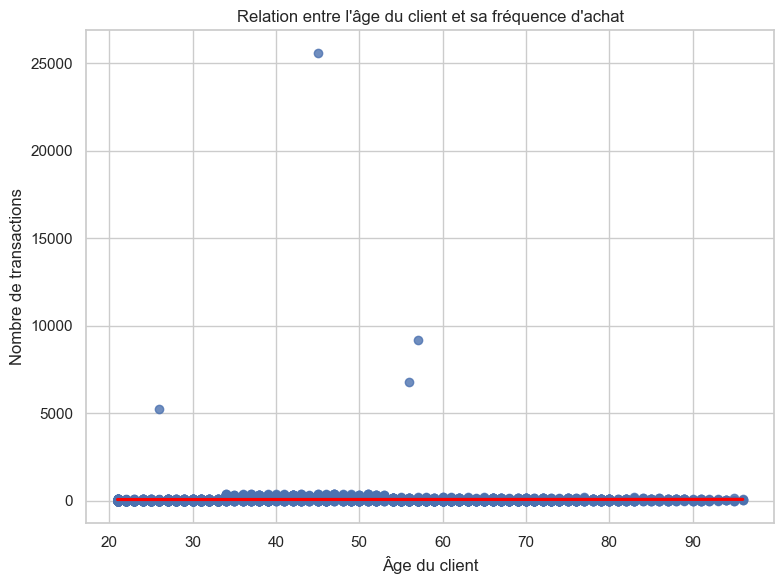

In [158]:
# AVEC CLIENTS B2B

# Étape 1 : Calcul du nombre de transactions par client
df_freq = df_vf.groupby('client_id').agg({
    'Age': 'first',  # âge supposé constant par client
    'session_id': 'count'  # nombre de transactions
}).rename(columns={'session_id': 'nb_transactions'}).reset_index()

# Étape 2 : Corrélation de Pearson
r, p_value = pearsonr(df_freq['Age'], df_freq['nb_transactions'])
print(f"📈 Coefficient de corrélation de Pearson : {r:.3f}")
print(f"p-value : {p_value:.4f}")

if p_value < 0.05:
    print("On rejette H0 : il existe une relation linéaire significative entre l'âge et la fréquence d'achat.")
else:
    print("On ne rejette pas H0 : pas de preuve suffisante d'une relation linéaire.")

# Étape 3 : Visualisation
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='nb_transactions', data=df_freq, ci=None, line_kws={"color": "red"})
plt.title("Relation entre l'âge du client et sa fréquence d'achat")
plt.xlabel("Âge du client")
plt.ylabel("Nombre de transactions")
plt.grid(True)
plt.tight_layout()
plt.show()

In [159]:
df_vf['type_client'].unique()

array([False,  True])

In [160]:
df_vf_particuliers = df_vf[df_vf['type_client'] == False]


📈 Coefficient de corrélation de Pearson : 0.030
p-value : 0.0049
On rejette H0 : il existe une relation linéaire significative entre l'âge et la fréquence d'achat.


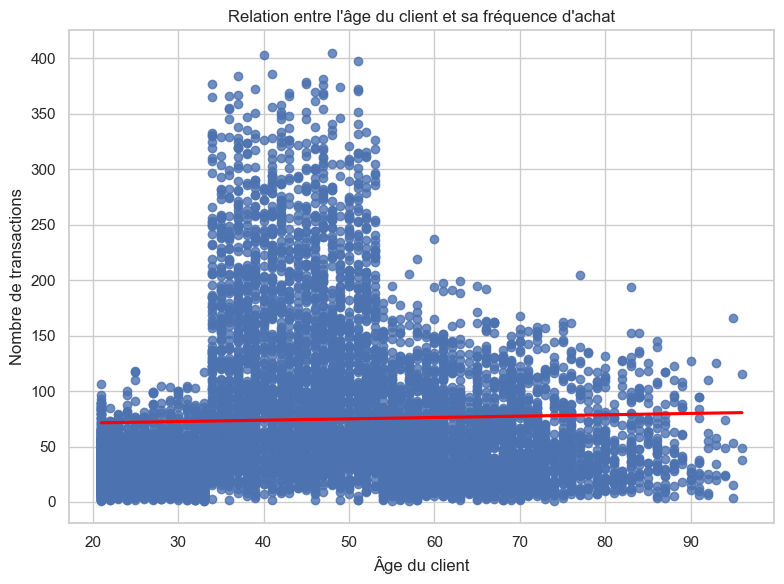

In [161]:
# SANS CLIENTS B2B
# Étape 1 : Calcul du nombre de transactions par client
df_freq = df_vf_particuliers.groupby('client_id').agg({
    'Age': 'first',  # âge supposé constant par client
    'session_id': 'count'  # nombre de transactions
}).rename(columns={'session_id': 'nb_transactions'}).reset_index()

# Étape 2 : Corrélation de Pearson
r, p_value = pearsonr(df_freq['Age'], df_freq['nb_transactions'])
print(f"📈 Coefficient de corrélation de Pearson : {r:.3f}")
print(f"p-value : {p_value:.4f}")

if p_value < 0.05:
    print("On rejette H0 : il existe une relation linéaire significative entre l'âge et la fréquence d'achat.")
else:
    print("On ne rejette pas H0 : pas de preuve suffisante d'une relation linéaire.")

# Étape 3 : Visualisation avec droite de régression (check pearson)
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='nb_transactions', data=df_freq, ci=None, line_kws={"color": "red"})
plt.title("Relation entre l'âge du client et sa fréquence d'achat")
plt.xlabel("Âge du client")
plt.ylabel("Nombre de transactions")
plt.grid(True)
plt.tight_layout()
plt.show()

In [162]:
from scipy.stats import spearmanr

# Application du test
r_spearman, p_spearman = spearmanr(df_freq['Age'], df_freq['nb_transactions'])

# Affichage des résultats
print(f"🔁 Coefficient de Spearman : {r_spearman:.3f}")
print(f"p-value : {p_spearman:.4f}")

# Interprétation
if p_spearman < 0.05:
    print("On rejette H0 : relation monotone significative entre l'âge et la fréquence d'achat.")
else:
    print("On ne rejette pas H0 : pas de preuve suffisante d'une relation monotone.")

🔁 Coefficient de Spearman : 0.128
p-value : 0.0000
On rejette H0 : relation monotone significative entre l'âge et la fréquence d'achat.


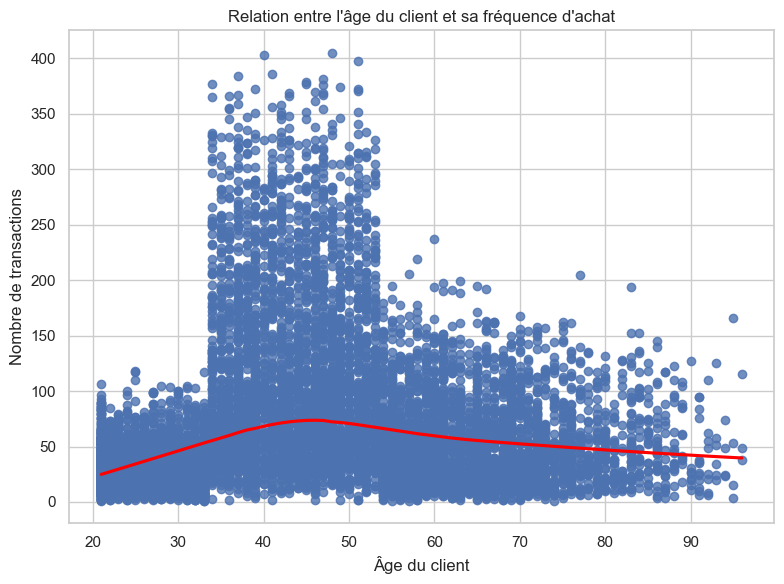

In [163]:
# Étape 3 : Visualisation avec droite lissée localement (check spearman)
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='nb_transactions', data=df_freq, lowess=True, line_kws={"color": "red"})
plt.title("Relation entre l'âge du client et sa fréquence d'achat")
plt.xlabel("Âge du client")
plt.ylabel("Nombre de transactions")
plt.grid(True)
plt.tight_layout()
plt.show()

🔍 Interprétation des résultats
- r = 0.030 → Le coefficient de corrélation est très faible et positif.
- Cela signifie qu’il existe une relation linéaire, mais elle est quasiment négligeable en termes de force.
- En clair : quand l’âge augmente, le montant des achats a tendance à augmenter très légèrement, mais ce n’est pas une tendance forte.
- p-value = 0.0049 → Elle est inférieure à 0.05, donc :
- Statistiquement significatif : on rejette H0.
- Mais attention : significatif ne veut pas dire important. La relation est détectable, mais elle n’est pas puissante.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.4 - Âge des clients et taille du panier moyen</h3>
</div>

1. Formulation des hypothèses
- H0 : Il n’y a pas de relation linéaire entre l’âge du client et la taille moyenne de son panier.
- H1 : Il existe une relation linéaire significative entre l’âge du client et la taille moyenne de son panier.

2. Choix du test :
Comme les deux variables sont quantitatives continues, on utilise :
- Le coefficient de corrélation de Pearson (r)
- La p-value associée

In [167]:
# Calcul de la taille moyenne du panier par clien
# Étape 1 : calculer la taille du panier par session
panier_par_session = df_vf.groupby('session_id').size().reset_index(name='taille_panier')

# Étape 2 : récupérer les infos client (client_id et Age) associées à chaque session
df_sessions = df_vf[['session_id', 'client_id', 'Age']].drop_duplicates()

# Étape 3 : fusionner les deux pour associer chaque session à son client et sa taille de panier
df_panier_client = pd.merge(panier_par_session, df_sessions, on='session_id')

# Étape 4 : calculer la taille moyenne du panier par client
panier_moyen_par_client = df_panier_client.groupby(['client_id', 'Age'])['taille_panier'].mean().reset_index(name='panier_moyen')

In [168]:
#Test de correlation
from scipy.stats import pearsonr

r, p_value = pearsonr(panier_moyen_par_client['Age'], panier_moyen_par_client['panier_moyen'])

print(f"Coefficient de corrélation de Pearson : {r:.3f}")
print(f"p-value : {p_value:.5f}")


Coefficient de corrélation de Pearson : -0.212
p-value : 0.00000


In [169]:
from scipy.stats import spearmanr

# Application du test
r_spearman, p_spearman = spearmanr(
    panier_moyen_par_client['Age'],
    panier_moyen_par_client['panier_moyen']
)

# Affichage des résultats
print(f"🔁 Coefficient de Spearman : {r_spearman:.3f}")
print(f"p-value : {p_spearman:.5f}")

🔁 Coefficient de Spearman : -0.207
p-value : 0.00000


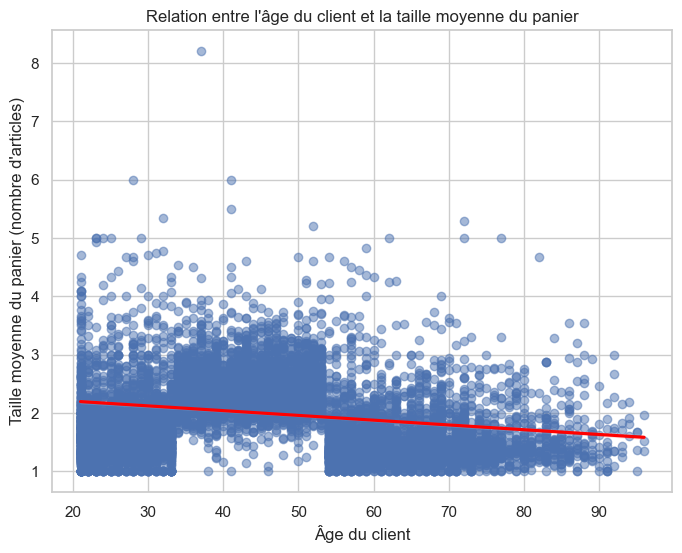

In [170]:
#visualisation avec droite de régression linéaire (check pearson)
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='panier_moyen', data=panier_moyen_par_client, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Relation entre l'âge du client et la taille moyenne du panier")
plt.xlabel("Âge du client")
plt.ylabel("Taille moyenne du panier (nombre d'articles)")
plt.grid(True)
plt.show()

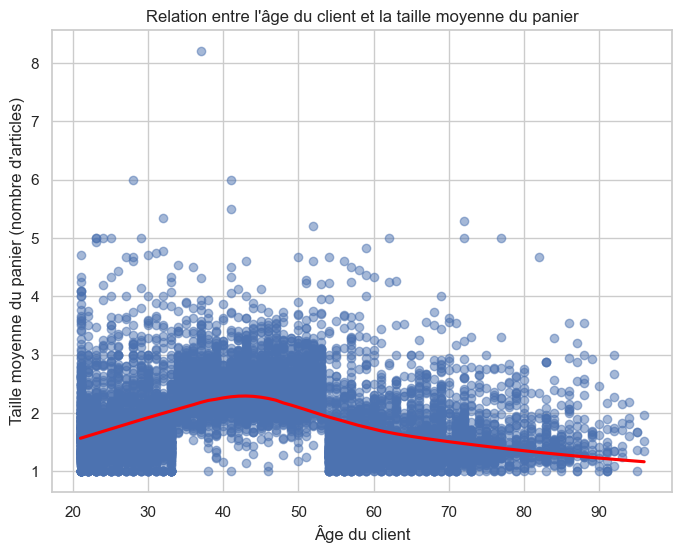

In [171]:
#visualisation avec droite lissée localement (check spearman)
plt.figure(figsize=(8, 6))
sns.regplot(x='Age', y='panier_moyen', data=panier_moyen_par_client, scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, lowess=True)
plt.title("Relation entre l'âge du client et la taille moyenne du panier")
plt.xlabel("Âge du client")
plt.ylabel("Taille moyenne du panier (nombre d'articles)")
plt.grid(True)
plt.show()

Coefficient de corrélation de Pearson : -0.212
- La corrélation est négative : plus l’âge augmente, plus la taille moyenne du panier diminue.
- La valeur -0.212 indique une corrélation faible, mais non négligeable.
- Cela suggère une tendance réelle, même si elle n’est pas dominante.

p-value : 0.00000
- La p-value est extrêmement faible, bien en dessous du seuil de 0.05.
- Cela signifie que cette relation est statistiquement significative.
- On peut donc rejeter H0 : il existe bien une relation linéaire entre l’âge et la taille moyenne du panier.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 6.5 - Âge des clients et catégorie des livres achetés</h3>
</div>

1. Formulation des hypothèses :
Puisque categ est une variable qualitative (valeurs 0, 1, 2), on ne cherche pas une relation linéaire mais une différence d’âge moyenne entre les groupes.
- H0 (hypothèse nulle) :
Il n’y a pas de différence significative entre les âges moyens des clients selon la catégorie de livre achetée.
- H1 (hypothèse alternative) :
Il existe une différence significative entre les âges moyens des clients selon la catégorie de livre achetée.

2. Choix du test statistique :
Comme on compare l’âge (quantitatif) entre plusieurs groupes (catégories), on utilise :
- Test KRUSKAL-WALLIS : adéquat aux distributions asymétriques avec outliers / compare plus de deux groupes (teste si au moins un groupe diffère des autres, sans dire lequel)
- Test de DUNN : montre quel groupe diffère des autres
- p-value associée :
Pour déterminer la significativité statistique du résultat.

3. Visualisation complémentaire
- Boxplot :
Pour visualiser la distribution des âges dans chaque catégorie et repérer les différences visuelles

In [175]:
from scipy.stats import kruskal
import scikit_posthocs as sp

# 1. Préparation des groupes
groupes = [df_vf[df_vf['categ'] == cat]['Age'] for cat in df_vf['categ'].unique()]

# 2. Test global de Kruskal-Wallis
stat, p = kruskal(*groupes)
print(f"Statistique H : {stat:.3f}")
print(f"p-value : {p:.5f}")

# 3. Si significatif, test post-hoc de Dunn
if p < 0.05:
    dunn = sp.posthoc_dunn(df_vf, val_col='Age', group_col='categ', p_adjust='bonferroni')
    print("\nRésultats du test de Dunn (p-values ajustées) :")
    print(dunn)


Statistique H : 78458.438
p-value : 0.00000

Résultats du test de Dunn (p-values ajustées) :
     0    1    2
0  1.0  0.0  0.0
1  0.0  1.0  0.0
2  0.0  0.0  1.0


Statistique H = 78458.438 → élevée, ce qui traduit une grande différence entre les groupes.

p-value ≈ 0.00000 → bien en dessous du seuil classique (0.05). On rejette H0

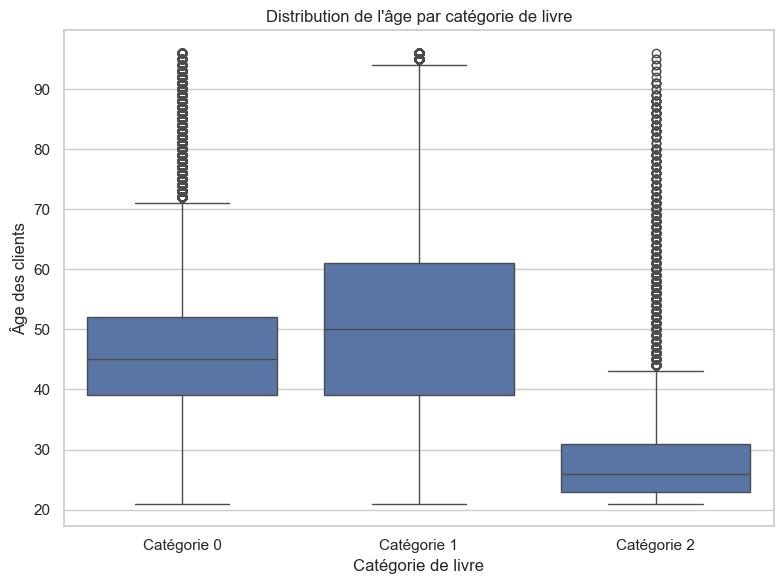

In [177]:
plt.figure(figsize=(8,6))
sns.boxplot(x='categ', y='Age', data=df_vf)
plt.title("Distribution de l'âge par catégorie de livre")
plt.xlabel("Catégorie de livre")
plt.ylabel("Âge des clients")
plt.xticks([0, 1, 2], ['Catégorie 0', 'Catégorie 1', 'Catégorie 2'])
plt.tight_layout()
plt.show()

<u>Description</u>
- Catégorie 0 : les clients ont un âge médian autour de 45 ans. Distribution assez homogène, mais avec des valeurs extrêmes (outliers) vers le haut.

- Catégorie 1 : médiane autour de 50 ans, mais beaucoup plus de dispersion (écart interquartile large, extrêmes jusqu’à 90 ans). Cette catégorie attire une clientèle plus âgée et variée.

- Catégorie 2 : médiane beaucoup plus basse (autour de 25 ans), distribution resserrée avec beaucoup d’outliers plus âgés. Cela indique que ce type de livres attire surtout un public jeune, mais pas exclusivement.

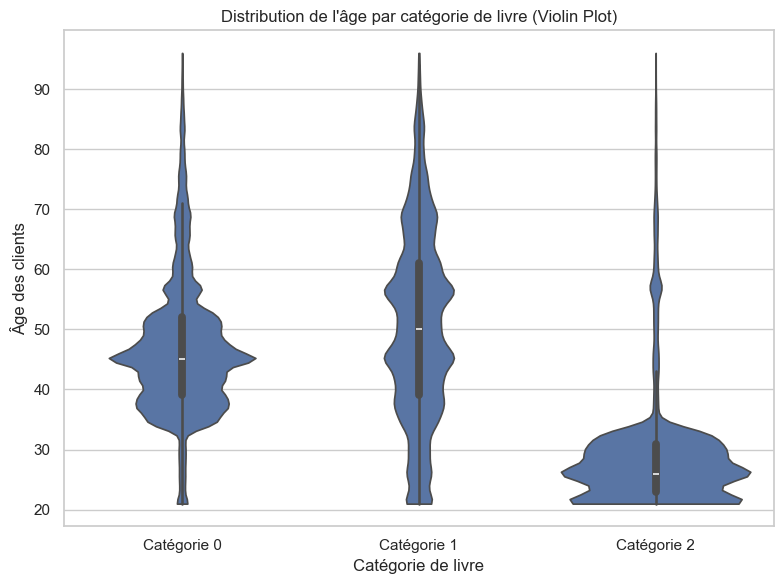

In [179]:
plt.figure(figsize=(8,6))
sns.violinplot(x='categ', y='Age', data=df_vf, inner='box', cut=0)

plt.title("Distribution de l'âge par catégorie de livre (Violin Plot)")
plt.xlabel("Catégorie de livre")
plt.ylabel("Âge des clients")
plt.xticks([0, 1, 2], ['Catégorie 0', 'Catégorie 1', 'Catégorie 2'])
plt.tight_layout()
plt.show()
